# Automated Warehouse Robot Controller

This notebook outlines the design and implementation of a multi-agent control system for coordinating a fleet of warehouse robots. The system coordinates multiple robots to retrieve shelves and deliver them to packing stations without collisions or deadlocks. Various **Multi-Agent Pathfinding (MAPF)** techniques, including **Independent A***, **Cooperative A***, **Hill Climbing Optimization**, and **Conflict-Based Search (CBS)**, are employed to find collision-free paths that minimize both makespan and flowtime. The project includes comprehensive performance evaluation, deadlock detection, and visual simulation with heatmap analysis of warehouse congestion patterns.


## Imports


In [82]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import psutil

import heapq
import concurrent.futures

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LogNorm

from collections import defaultdict, deque
from itertools import product
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set, Any

print("Imports completed.")

Imports completed.


# 1.Data Collection And Research

## Data Set Building

### Source and Acquisition
The dataset was created from the architectural floor plans of the  Algerian prominent manufacturing company BMS. The first and second floors were digitized into a machine-readable **182 × 71 grid**, forming the project’s local dataset. This provides a realistic warehouse environment for evaluating multi-agent pathfinding systems alongside standard MovingAI benchmarks.

### Objective of Data Collection and Analysis
The dataset was designed to simulate a high-fidelity environment for automated warehouse robots. Its main objectives are:

- **MAPF Coordination:** Supporting algorithms such as Cooperative A* and CBS for conflict-free path planning in space and time.
- **Collision and Deadlock Prevention:** Detecting narrow corridors and intersections where edge conflicts or deadlocks are likely to occur.
- **Task List Generation:** Creating realistic pick lists by ranking storage zones according to access frequency, enabling lifelong MAPF simulations.

### Data Representation and Resolution
The warehouse is represented as a discrete 2D occupancy grid:

- `.` → Walkable cells where robots can move and transport shelves.
- `T` → Obstacles such as storage racks, pillars, and elevators.

**Scaling Factor and Precision:**


A **1:4 scaling ratio** is applied, where each physical `1 m²` corresponds to a `2 × 2` grid block. This produces a resolution of **0.5 m per cell**, enabling:

- **Safety Buffers:** Maintaining safe distances between robots.
- **Granular Movement:** Allowing precise movements and wait actions in narrow areas without occupying excessive operational space.




### Grid Envirenment Class
This class represents the warehouse as a grid-based environment that manages boundaries, obstacles, and valid robot movements.

GridEnvironment class defined.


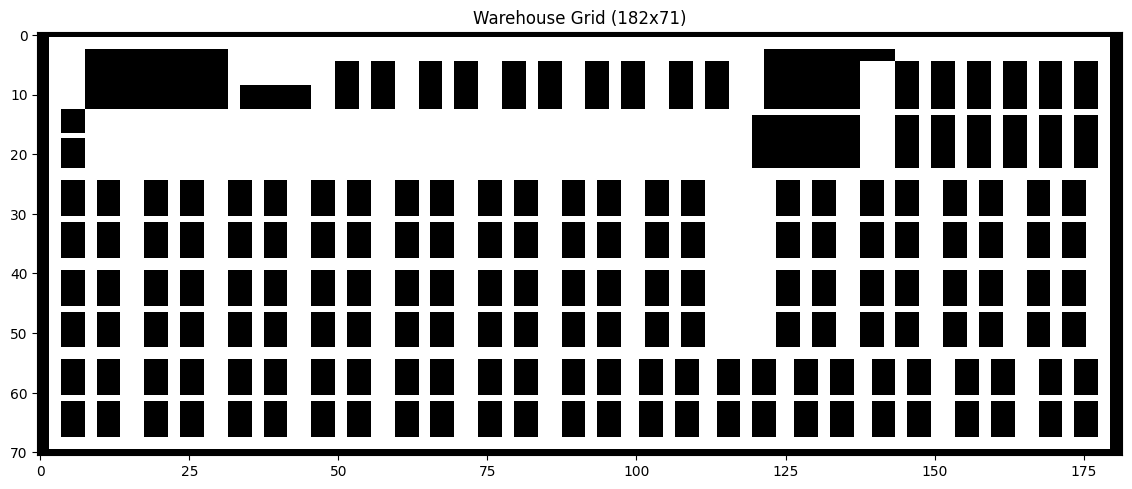

In [83]:
class GridEnvironment:
    """
    Represents a 2D grid-based warehouse environment.
    """

    def __init__(self, filename : str, size=None):
        """ Load grid from file """

        # This is a bit hacky but allows us to create an empty grid if size is provided, otherwise load from file
        # It is used for testing purposes to create a simple grid without needing a file
        if size is not None:
            self.width, self.height = size
            self.grid = [[True for _ in range(self.width)] for _ in range(self.height)]
        else:
            self.grid = self.load_from_file(filename)
        self.height = len(self.grid)
        self.width = len(self.grid[0]) if self.height > 0 else 0

    def is_valid_position(self, x, y):
        """ Check if position is within grid bounds """
        return 0 <= x < self.width and 0 <= y < self.height

    def is_walkable(self, x, y):
        """ Check if position is walkable (not obstacle)"""
        return self.is_valid_position(x, y) and self.grid[y][x]

    def get_neighbors(self, x, y):
        """Get adjacent cells (4-directional)"""
        directions = [(0,1), (1,0), (0,-1), (-1,0)]
        neighbors = []
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_walkable(nx, ny):
                neighbors.append((nx, ny))
        return neighbors

    def manhattan_distance(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def load_from_file(self, filename):
        """ Load grid from file (robust format handling) """
        grid = []
        max_w = 0
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            # First pass to find max width
            for line in lines:
                l = line.strip()
                if l: max_w = max(max_w, len(l))
            
            # Second pass to build grid
            for line in lines:
                l = line.strip()
                if not l: continue
                # Pad shorter lines with obstacles (T) if inhomogeneous
                l = l.ljust(max_w, 'T')
                row = []
                for char in l:
                    # '.' is walkable, anything else is obstacle
                    if char == '.':
                        row.append(True)
                    else:
                        row.append(False)
                grid.append(row)
        return grid

    def visualize(self):
        from matplotlib.colors import ListedColormap
        grid_array = np.array(self.grid, dtype=int)
        fig, ax = plt.subplots(figsize=(14,14))
        cmap = ListedColormap(['black', 'white'])
        ax.imshow(grid_array, cmap=cmap, origin='upper')
        ax.set_title(f"Warehouse Grid ({self.width}x{self.height})")
        plt.show()

print("GridEnvironment class defined.")

test_grid = GridEnvironment('grid.txt').visualize()


# 2. Problem Definition


Given N robots at start positions and N goal positions (shelves to retrieve), find a set of
conflict-free paths such that all robots reach their goals in minimal time.

## Search Problem Formulation:
### 1. State Representation

Each state is represented by a dictionary with the following structure:

```python
state = {
    # The Robots
    'robots': [
        {
            'id': robot_id,                             # Unique identifier (0, 1, 2, ...)
            'start_position': (x0, y0),                 # Start postion (fixed)
            'goal_position': (gx, gy),                  # Goal position (fixed)
            'at_goal': bool,                            # True if positions[robot_id] == goal_position
            'color': str                                # The color of the robot, used for visualization stuff
        },
        # ... more robots
    ],
    
    # Global state
    'positions': {robot_id: (x, y)},          # Current position of the robot in the grid given its id
    'collisions': count,                      # Cumulative collision count
    'deadlock': bool,                         # True if circular wait detected
    'grid': GridEnvironment                   # Reference to warehouse layout
}
```

### 2. Goal Test

**Primary Goal**:
- All robots at their goal positions


**Success Criteria: (Detail)**
1. All robots reach goals 
2. No collisions/conflicts 
3. No deadlocks 
4. Minimum makespan  (secondary objective)
5. Minimum flowtime  (secondary objective)

### 3. Actions
- All robots move simultaneously, some could wait

- SubActions per robot: 
    - MoveUp: move up if walkable (path = [..., (x, y), (x - 1, y), ...]) 


    - MoveDown: move down if walkable (path = [..., (x, y), (x + 1, y), ...]) 


    - MoveLeft: move left if walkable (path = [..., (x, y), (x, y - 1), ...]) 


    - MoveRight: move right if walkable (path = [..., (x, y), (x, y + 1), ...]) 


    - Wait: stay in current position (path = [..., (x, y), (x, y), ...]) 



### 4. Transition Model
- The new state after applying the action:
    - The new position for each robot is added to its path, if it is a wait just add the last position to the path i.e. [..., (x, y), (x, y), ...]

    - Each robot may reach its goal_position, hence the attribute 'at_goal' may be updated 

    - The positions of the robots is changed

    - The number of collisions in the state is updated

    - The deadlock state is update (a deadlock may occur)

### 5. Path Cost

- Each move costs: 1 time unit
- Each wait costs: 1 time unit

### Initial State

**Properties of Initial State:**
- All robots' positions are walkable and valid within the grid
- All robots at distinct start positions
- All start positions are walkable
- No paths planned yet
- No conflicts exist initially
- Time counter starts at 0
- Cost g(n) = 0 (no moves yet)


**Initial State Example:**
```python
initial_state = {
    'robots': [
        {'id': 1, 'start_position': (1, 1), 'goal_position': (8, 8), 'at_goal': False},
        {'id': 2, 'start_position': (8, 1), 'goal_position': (1, 8), 'at_goal': False},
        {'id': 3, 'start_position': (1, 8), 'goal_position': (8, 1), 'at_goal': False},
    ],
    'positions': {1: (1, 1), 2: (8, 1), 3: (1, 8)}
    'collisions': 0,
    'deadlock': False,
    'grid': GridEnvironment(filename)
}
```

- Robot 1: starts at (1,1), goal (8,8)
- Robot 2: starts at (8,1), goal (1,8)
- Robot 3: starts at (1,8), goal (8,1)
- Robots' positions are their starting positions
- No collisions 
- No deadlock
- Grid loaded from the file


## Constraints Search Problem Formulation (For Conflict Based Search):

- **Variables** represent the paths assigned to each robot.

- **Domains** contain all possible valid paths from the robot's start position to its goal position.

- **Constraints** ensure collision-free movement:
  - No **vertex collisions**: two robots cannot occupy the same cell at the same time.
  - No **edge collisions**: two robots cannot swap positions during the same time step.

## Problem Class
Now, let's define the main Problem class that will encapsulate our MAPF problem

In [84]:
class AutomatedWarehouseRobotControllerProblem:
    """
    Encapsulates the MAPF problem for N warehouse robots.
    """

    def __init__(self, initial_state):
        self.state = copy.deepcopy(initial_state)
        for robot in self.state['robots']:
            if 'path' not in robot:
                robot['path'] = [self.state['positions'][robot['id']]]

    def is_goal(self, state=None) -> bool:
        s = state if state is not None else self.state
        if s.get('collisions', 0) > 0 or s.get('deadlock', False):
            return False
        return all(robot['at_goal'] for robot in s['robots'])

    def get_valid_actions(self, state) -> list:
        grid = state['grid']
        positions = state['positions']
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (0, 0)]

        per_robot_moves = {}
        for robot in state['robots']:
            rid = robot['id']
            x, y = positions[rid]
            moves = []
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if grid.is_walkable(nx, ny):
                    moves.append((nx, ny))
            per_robot_moves[rid] = moves

        robot_ids = list(per_robot_moves.keys())
        move_lists = [per_robot_moves[rid] for rid in robot_ids]
        valid_joint_actions = []
        for combo in product(*move_lists):
            joint = dict(zip(robot_ids, combo))
            if not self._has_edge_conflict_in_action(positions, joint):
                valid_joint_actions.append(joint)
        return valid_joint_actions

    def _has_edge_conflict_in_action(self, positions, joint_action) -> bool:
        ids = list(joint_action.keys())
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                a, b = ids[i], ids[j]
                if (joint_action[a] == positions[b] and
                        joint_action[b] == positions[a]):
                    return True
        return False

    def apply_action(self, state, action) -> dict:
        new_state = copy.deepcopy(state)
        new_positions = {}
        for robot in new_state['robots']:
            rid = robot['id']
            next_pos = action[rid]
            new_positions[rid] = next_pos
            robot['path'].append(next_pos)
            robot['at_goal'] = (next_pos == robot['goal_position'])
        new_state['positions'] = new_positions
        return new_state

    def get_makespan(self, state=None) -> int:
        s = state if state is not None else self.state
        lengths = [len(r.get('path', [])) - 1 for r in s['robots']]
        return max(lengths) if lengths else 0

    def get_flowtime(self, state=None) -> int:
        s = state if state is not None else self.state
        return sum(len(r.get('path', [])) - 1 for r in s['robots'])

print("Problem class defined.")

Problem class defined.


# 3. Constraints And Objective Function

In this multi-robot pathfinding setup, the system is designed to ensure that robots move safely while also optimizing overall performance.

### Constraints

**Hard constraints**
- Robots must never share the same grid cell at the same time step (vertex conflict).
- Direct swaps are forbidden, meaning two robots cannot cross positions in opposite directions in one step.

**Soft constraints**
- Prefer keeping a safety margin between robots when possible.
- Reduce unnecessary waiting so robots avoid staying idle longer than needed.

### Objective

The goal is to find paths that are both safe and efficient:

- **Makespan minimization**: reduce the total completion time until the slowest robot reaches its goal.
- **Flowtime minimization**: reduce the overall sum of travel times across all robots.

---

## ConflictDetector Class:

(what it does)

This component checks planned robot trajectories and finds where collisions happen in time. It first aligns all paths to the same length by extending them at the goal position, then scans step-by-step to detect both overlapping positions and path swaps between robots. It is mainly used for debugging and evaluating multi-agent path planning solutions.

In [85]:
class ConflictDetector:
    """
    Combined Conflict Detection System.
    """

    def __init__(self):
        pass

    def pad_paths(self, paths: Dict) -> Dict:
        if not paths: return {}
        # Filter out None paths
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        if not valid_paths: return {}
        
        max_time = max(len(path) for path in valid_paths.values())
        padded_paths = {}
        for robot_id, path in valid_paths.items():
            goal_pos = path[-1]
            padded_paths[robot_id] = path + [goal_pos] * (max_time - len(path))
        return padded_paths

    def detect_conflicts(self, paths: Dict) -> List[Dict]:
        conflicts = []
        padded = self.pad_paths(paths)
        if not padded: return []
        
        robot_ids = list(padded.keys())
        horizon = len(next(iter(padded.values())))

        for t in range(horizon):
            # Vertex Detection
            pos_map = defaultdict(list)
            for rid in robot_ids:
                pos = padded[rid][t]
                pos_map[pos].append(rid)
            for pos, robots in pos_map.items():
                if len(robots) > 1:
                    conflicts.append({'type': 'vertex', 'time': t, 'pos': pos, 'robots': robots})
            
            # Swap Detection
            if t < horizon - 1:
                for i, r1 in enumerate(robot_ids):
                    for r2 in robot_ids[i+1:]:
                        if padded[r1][t] == padded[r2][t+1] and padded[r1][t+1] == padded[r2][t] and padded[r1][t] != padded[r1][t+1]:
                            conflicts.append({'type': 'swap', 'time': t, 'robots': [r1, r2], 'pos': (padded[r1][t], padded[r1][t+1])})
        return conflicts

    def get_report(self, paths: Dict):
        conflicts = self.detect_conflicts(paths)
        print(f"Total conflicts detected: {len(conflicts)}")
        for i, c in enumerate(conflicts[:10]):
            print(f"  {i+1}. {c['type']} at t={c['time']} involving robots {c['robots']}")
        if len(conflicts) > 10:
            print(f"  ... and {len(conflicts)-10} more.")
        return conflicts

print("ConflictDetector class defined.")

ConflictDetector class defined.


## Constraint Class (For CBS):

This class represents a single rule used in Conflict-Based Search (CBS) to prevent collisions between agents during path planning.

It can describe either a **vertex constraint** (forbidding an agent from being in a specific cell at a given time) or an **edge constraint** (forbidding a move between two consecutive cells at a given time step).

The class also includes comparison and hashing methods so constraints can be stored efficiently in sets and compared reliably. It supports clear printing for debugging by showing whether the constraint is vertex-based or edge-based, along with the affected agent, position(s), and time.

In [86]:
class Constraint:
    """
    CBS constraint.

    Vertex constraint:
        agent cannot be at pos1 at time t

    Edge constraint:
        agent cannot move pos1 -> pos2 at time t
    """
    def __init__(self, agent_id: int, pos1: Tuple, pos2: Optional[Tuple] = None, time: int = None):
        self.agent_id = agent_id
        self.pos1 = pos1
        self.pos2 = pos2
        self.time = time
        self.is_edge = pos2 is not None

    def __repr__(self):
        if self.is_edge:
            return f"Edge({self.agent_id}: {self.pos1}->{self.pos2}@t={self.time})"
        return f"Vertex({self.agent_id}: {self.pos1}@t={self.time})"

    def __eq__(self, other):
        return (
            isinstance(other, Constraint)
            and self.agent_id == other.agent_id
            and self.pos1 == other.pos1
            and self.pos2 == other.pos2
            and self.time == other.time
        )

    def __hash__(self):
        return hash((self.agent_id, self.pos1, self.pos2, self.time))

# 4. Search Strategy Implementation

## Node Class (Pathfinding)

This class represents a single state in a search tree used for pathfinding (e.g., A*). Each node stores its position, cost values, and a link to its parent so that a full path can be reconstructed.

It supports priority queue ordering using the total cost `f = g + h`, equality checks based on state, and hashing for efficient storage in sets and dictionaries. It also includes a helper method to rebuild the final path from the start node by following parent links backward.

In [87]:
class Node:
    """Represents a node in the search tree"""

    def __init__(self, position, parent=None, g=0, h=0):
        """Initialize a node for pathfinding
        
        Args:
            position (tuple): (x, y) coordinate or state dictionary
            parent (Node): Parent node in the path
            g (float): Cost from start to this node
            h (float): Heuristic cost from this node to goal
        """
        self.position = position
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h
        self.depth = 0 if parent is None else parent.depth + 1

    def __lt__(self, other):
        """Compare nodes for priority queue (min-heap by f value)"""
        return self.f < other.f

    def __eq__(self, other):
        """Check if two nodes represent the same position/state"""
        return self.position == other.position

    def __hash__(self):
        """Hash function for use in sets and dicts"""
        if isinstance(self.position, dict):
             return hash(str(sorted(self.position.items())))
        return hash(self.position)

    def reconstruct_path(self):
        """Reconstruct path from start to this node"""
        path = []
        current = self
        while current is not None:
            path.append(current.position)
            current = current.parent
        return list(reversed(path))

    def __repr__(self):
        return f"Node(pos={self.position}, f={self.f})"

print("Node class defined.")



Node class defined.


## ConflictTreeNode (CBS)

This class represents a node in the CBS search tree. It stores the current constraints, the planned paths for all agents, and any detected conflicts.

It also computes two cost metrics:
- **Makespan**: completion time of the slowest agent
- **Flowtime**: total travel time of all agents

It is mainly used in the high-level search to evaluate and compare different constrained solutions.

In [88]:
class ConflictTreeNode:
    def __init__(
        self,
        constraints: Optional[Dict[int, List[Constraint]]] = None,
        paths: Optional[Dict[int, List]] = None,
        conflicts: Optional[List[Dict]] = None,
    ):
        self.constraints = constraints if constraints is not None else defaultdict(list)
        self.paths = paths if paths is not None else {}
        self.conflicts = conflicts if conflicts is not None else []
        self.makespan = self._calculate_makespan()
        self.flowtime = self._calculate_flowtime()

    def _calculate_makespan(self) -> float:
        if not self.paths:
            return float("inf")
        valid_paths = [p for p in self.paths.values() if p is not None and len(p) > 0]
        if not valid_paths:
            return float("inf")
        return max(len(p) for p in valid_paths) - 1

    def _calculate_flowtime(self) -> float:
        if not self.paths:
            return float("inf")
        valid_paths = [p for p in self.paths.values() if p is not None and len(p) > 0]
        if not valid_paths:
            return float("inf")
        return sum(len(p) - 1 for p in valid_paths)

    def __repr__(self):
        return f"CTNode(makespan={self.makespan}, flowtime={self.flowtime}, conflicts={len(self.conflicts)})"


## 4.1. Search Strategy Implementations

### 4.1.1. A* Search Algorithm:

#### A* Base Class

A core implementation of the A* search algorithm designed for pathfinding. It combines cost-so-far and heuristic estimates to efficiently explore the search space.

This base class also integrates:
- Heuristic evaluation for guiding the search
- Conflict checking for multi-agent scenarios
- Reservation table support to avoid collisions over time

In [89]:
class A_Star:
    """
    Base A* class.
    """

    def __init__(self, problem, strategy: str = "base"):
        self.problem = problem
        self.strategy = strategy

    def heuristic(self, x: int, y: int, gx: int, gy: int) -> int:
        return abs(x - gx) + abs(y - gy)

    def _check_vertex_conflict(self, pos: tuple, t: int, reservation_table: set) -> bool:
        return (pos[0], pos[1], t) in reservation_table

    def _check_edge_conflict(self, pos_from: tuple, pos_to: tuple, t: int, reservation_table: set) -> bool:
        other_was_at_to   = (pos_to[0],   pos_to[1],   t - 1) in reservation_table
        other_goes_to_src = (pos_from[0], pos_from[1], t    ) in reservation_table
        return other_was_at_to and other_goes_to_src

    def _build_reservation_table(self, paths: list) -> set:
        if not paths: return set()
        max_len = max(len(p) for p in paths)
        table = set()
        for path in paths:
            for t, pos in enumerate(path):
                table.add((pos[0], pos[1], t))
            if path:
                goal = path[-1]
                # Increased reservation horizon from 50 to 500
                for t in range(len(path), max_len + 500): 
                    table.add((goal[0], goal[1], t))
        return table

    def _astar_single_robot(self, robot, grid, reservation_table: set, start_time: int = 0, max_time: int = 1500):
        # Increased max_time from 500 to 1500
        sx, sy = robot.start_pos
        gx, gy = robot.goal_pos
        h0 = self.heuristic(sx, sy, gx, gy)
        open_heap = [(h0, 0, sx, sy, start_time)]
        came_from = {(sx, sy, start_time): None}
        g_score = {(sx, sy, start_time): 0}
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (0, 0)]

        while open_heap:
            f, g, x, y, t = heapq.heappop(open_heap)
            if (x, y) == (gx, gy):
                return self._reconstruct_path(came_from, (x, y, t))
            if t >= max_time: continue
            if g > g_score.get((x, y, t), float('inf')): continue

            nt = t + 1
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if not grid.is_walkable(nx, ny): continue
                if self._check_vertex_conflict((nx, ny), nt, reservation_table): continue
                if (dx, dy) != (0, 0) and self._check_edge_conflict((x, y), (nx, ny), nt, reservation_table):
                    continue

                new_g = g + 1
                new_state = (nx, ny, nt)
                if new_g < g_score.get(new_state, float('inf')):
                    g_score[new_state] = new_g
                    came_from[new_state] = (x, y, t)
                    h = self.heuristic(nx, ny, gx, gy)
                    heapq.heappush(open_heap, (new_g + h, new_g, nx, ny, nt))
        return None

    def _reconstruct_path(self, came_from: dict, goal_state: tuple) -> list:
        path = []
        current = goal_state
        while current is not None:
            path.append((current[0], current[1]))
            current = came_from[current]
        return list(reversed(path))

    def solve(self):
        raise NotImplementedError("Subclasses must implement solve().")

class _RobotProxy:
    def __init__(self, start_pos, goal_pos):
        self.start_pos = start_pos
        self.goal_pos = goal_pos

print("A_Star base class defined.")

A_Star base class defined.


#### Independent A*

Each robot finds its path independently without considering other robots. Fast but may produce conflicts.

In [90]:
class IndependentAStar(A_Star):
    """
    Independent A* (inherited from Mother Class).
    """

    def __init__(self, problem):
        super().__init__(problem, strategy="independent")

    def _astar_2d(self, robot, grid):
        """Fast 2D A* search since we ignore other agents and reservations."""
        sx, sy = robot.start_pos
        gx, gy = robot.goal_pos
        h0 = self.heuristic(sx, sy, gx, gy)
        open_heap = [(h0, 0, sx, sy)]
        came_from = {(sx, sy): None}
        g_score = {(sx, sy): 0}
        # No need to wait (0, 0) since we are the only agent in our universe
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0)]
        
        while open_heap:
            f, g, x, y = heapq.heappop(open_heap)
            if (x, y) == (gx, gy):
                path = []
                curr = (x, y)
                while curr is not None:
                    path.append(curr)
                    curr = came_from[curr]
                return list(reversed(path))
            
            if g > g_score.get((x, y), float('inf')): 
                continue

            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if not grid.is_walkable(nx, ny): 
                    continue

                new_g = g + 1
                if new_g < g_score.get((nx, ny), float('inf')):
                    g_score[(nx, ny)] = new_g
                    came_from[(nx, ny)] = (x, y)
                    h = self.heuristic(nx, ny, gx, gy)
                    heapq.heappush(open_heap, (new_g + h, new_g, nx, ny))
        return None

    def solve(self) -> dict:
        state = self.problem.state
        grid = state['grid']
        paths = {}
        for robot_data in state['robots']:
            rid = robot_data['id']
            robot_proxy = _RobotProxy(robot_data['start_position'], robot_data['goal_position'])
            
            # Use the much faster 2D A*
            path = self._astar_2d(robot_proxy, grid)
            paths[rid] = path

        valid_paths = [p for p in paths.values() if p is not None]
        makespan = max(len(p) for p in valid_paths) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths) if valid_paths else 0

        return {
            'paths': paths,
            'success': all(p is not None for p in paths.values()),
            'makespan': makespan,
            'flowtime': flowtime,
        }

print("IndependentAStar class defined.")

IndependentAStar class defined.


#### Cooperative A*

Robots coordinate using reservation tables to avoid conflicts. Paths are computed sequentially with cumulative reservation.

In [91]:
class CooperativeAStar(A_Star):
    """
    Cooperative A* (inherited from Mother Class).
    """

    def __init__(self, problem, priority_order: list = None):
        super().__init__(problem, strategy="cooperative")
        self.priority_order = priority_order

    def solve(self) -> dict:
        state = self.problem.state
        grid = state['grid']
        robot_by_id = {r['id']: r for r in state['robots']}
        
        # Smart priority ordering: shorter paths first
        if not self.priority_order:
            order = sorted(robot_by_id.keys(), 
                           key=lambda r: grid.manhattan_distance(
                               robot_by_id[r]['start_position'], 
                               robot_by_id[r]['goal_position']
                           ))
        else:
            order = self.priority_order

        reservation_table = set()
        paths = {}
        
        # Pre-calculate max horizon for incremental updates
        all_mht = [grid.manhattan_distance(robot_by_id[r]['start_position'], robot_by_id[r]['goal_position']) for r in order]
        max_horizon = max(all_mht) * 3 + 500

        for rid in order:
            rd = robot_by_id[rid]
            robot_proxy = _RobotProxy(rd['start_position'], rd['goal_position'])
            path = self._astar_single_robot(robot_proxy, grid, reservation_table)
            paths[rid] = path
            if path:
                # Incremental reservation update (O(path_length) instead of rebuilding)
                for t, pos in enumerate(path):
                    reservation_table.add((pos[0], pos[1], t))
                goal = path[-1]
                for t in range(len(path), max_horizon):
                    reservation_table.add((goal[0], goal[1], t))

        valid_paths = [p for p in paths.values() if p is not None]
        makespan = max(len(p) for p in valid_paths) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths) if valid_paths else 0

        return {
            'paths': paths,
            'success': all(p is not None for p in paths.values()),
            'makespan': makespan,
            'flowtime': flowtime,
        }

print("CooperativeAStar class defined.")

CooperativeAStar class defined.


### 4.1.2. Hill Climbing Optimizer:

This class improves already-planned multi-robot paths using a local search approach. It iteratively tries small modifications that reduce conflicts and path cost while keeping solutions valid.

It applies several strategies:
- Removing loops and redundant cycles
- Compressing unnecessary waiting steps
- Replacing inefficient segments with shorter detours
- Randomized local shortcut attempts on the longest path

At each step, it only accepts changes that keep paths valid and reduce both conflicts and overall cost (makespan + safety consistency). It is mainly used as a post-processing optimizer after initial path planning.

In [92]:
class HillClimbingOptimizer:
    """
    Hill Climbing optimizer for MAPF path improvement.

    Strategies:
    1. Path Shortening: remove internal loops and redundant segments
    2. Idle Reduction: compress consecutive waiting actions
    3. Local Swap Optimization: replace a local corner with a shorter detour
    4. Adaptive Local Search: random shortcut attempts on the longest path
    """

    def __init__(self, conflict_detector=None):
        self.conflict_detector = conflict_detector or ConflictDetector()
        self.iteration_count = 0

    def optimize(
        self,
        paths: Dict,
        grid,
        max_iterations: int = 1000,
        timeout: float = 30
    ) -> Dict:
        """
        Optimize MAPF paths using a safe hill-climbing procedure.

        Args:
            paths: Dictionary of robot_id -> path
            grid: Grid environment
            max_iterations: Maximum iterations
            timeout: Timeout in seconds

        Returns:
            Optimized paths dictionary
        """
        start_time = time.time()
        original_paths = copy.deepcopy(paths)

        best_paths = copy.deepcopy(paths)
        best_score = self._solution_score(best_paths, grid, original_paths)

        improved = True
        iteration = 0

        while improved and iteration < max_iterations:
            if time.time() - start_time > timeout:
                break

            improved = False
            iteration += 1

            # Strategy 1: Path Shortening
            new_paths = self._optimize_path_shortening(best_paths, grid)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

            # Strategy 2: Idle Reduction (kept minimal to preserve collision avoidance)
            new_paths = self._optimize_idle_reduction(best_paths)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

            # Strategy 3: Local Swap Optimization
            new_paths = self._optimize_path_swaps(best_paths, grid)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

            # Strategy 4: Adaptive Local Search
            new_paths = self._optimize_adaptive_local_search(best_paths, grid)
            if self._is_better(new_paths, best_score, best_paths, grid, original_paths):
                best_paths = new_paths
                best_score = self._solution_score(best_paths, grid, original_paths)
                improved = True
                continue

        self.iteration_count = iteration
        return best_paths

    def _optimize_path_shortening(self, paths: Dict, grid) -> Dict:
        """
        Remove internal loops from paths.

        The start and goal of each robot are preserved.
        """
        optimized = copy.deepcopy(paths)

        for rid, path in optimized.items():
            if not path or len(path) <= 2:
                continue

            candidate = self._remove_internal_loops(path)

            if candidate != path:
                test_paths = copy.deepcopy(optimized)
                test_paths[rid] = candidate
                # Check if conflicts exist (non-empty list) before rejecting
                conflicts = self.conflict_detector.detect_conflicts(test_paths)
                if conflicts:  # Only reject if conflicts found
                    continue
                if self._is_structurally_valid_solution(test_paths, grid, paths):
                    optimized = test_paths

        return optimized

    def _optimize_idle_reduction(self, paths: Dict) -> Dict:
        """
        Reduce idle time by compressing consecutive waiting actions.
        NOTE: Only removes back-to-back duplicates to preserve collision avoidance waiting.
        """
        optimized = copy.deepcopy(paths)

        for rid, path in optimized.items():
            if not path or len(path) <= 1:
                continue

            candidate = [path[0]]

            for pos in path[1:]:
                if pos != candidate[-1]:
                    candidate.append(pos)

            if candidate != path:
                test_paths = copy.deepcopy(optimized)
                test_paths[rid] = candidate
                # Check if conflicts exist before rejecting
                conflicts = self.conflict_detector.detect_conflicts(test_paths)
                if conflicts:  # Only reject if conflicts found
                    continue

                if self._is_structurally_valid_solution(test_paths, None, paths):
                    optimized = test_paths

        return optimized

    def _optimize_path_swaps(self, paths: Dict, grid) -> Dict:
        """
        Try local corner swaps by replacing one waypoint with a shorter detour.

        This does NOT swap entire robot paths, because that would break starts/goals.
        """
        optimized = copy.deepcopy(paths)
        robot_ids = list(optimized.keys())

        for rid in robot_ids:
            path = optimized.get(rid)
            if not path or len(path) < 3:
                continue

            for idx in range(1, len(path) - 1):
                prev_pos = path[idx - 1]
                next_pos = path[idx + 1]

                alt_path = self._find_detour(prev_pos, next_pos, grid, max_steps=4)
                if not alt_path:
                    continue

                # Accept if alt_path is strictly shorter
                # alt_path includes start and end, so length should be < 3 to improve
                if len(alt_path) >= 3:  # Must be 2 or fewer intermediate steps
                    continue

                candidate = path[:idx] + alt_path[1:-1] + path[idx + 1:]

                if candidate != path:
                    test_paths = copy.deepcopy(optimized)
                    test_paths[rid] = candidate
                    # Check if conflicts exist before rejecting
                    conflicts = self.conflict_detector.detect_conflicts(test_paths)
                    if conflicts:  # Only reject if conflicts found
                        continue
                    if self._is_structurally_valid_solution(test_paths, grid, paths):
                        optimized = test_paths
                        break

        return optimized

    def _optimize_adaptive_local_search(self, paths: Dict, grid) -> Dict:
        """
        Adaptive local search: randomly try to shortcut a segment of the longest path.
        """
        optimized = copy.deepcopy(paths)

        valid_robot_ids = [
            rid for rid, p in optimized.items()
            if p is not None and len(p) >= 3
        ]
        if not valid_robot_ids:
            return optimized

        longest_rid = max(valid_robot_ids, key=lambda r: len(optimized[r]))
        path = optimized[longest_rid]

        attempts = min(8, len(path) - 2)

        for _ in range(attempts):
            i = random.randint(0, len(path) - 3)
            j = random.randint(i + 2, min(len(path) - 1, i + 8))

            start = path[i]
            end = path[j]

            alt_path = self._find_detour(start, end, grid, max_steps=(j - i + 2))
            if not alt_path:
                continue

            # Need a real improvement in segment length.
            if len(alt_path) >= (j - i + 1):
                continue

            candidate_path = path[:i] + alt_path + path[j + 1:]

            test_paths = copy.deepcopy(optimized)
            test_paths[longest_rid] = candidate_path

            # Check if conflicts exist before rejecting
            conflicts = self.conflict_detector.detect_conflicts(test_paths)
            if conflicts:  # Only reject if conflicts found
                continue

            if self._is_structurally_valid_solution(test_paths, grid, paths):
                optimized = test_paths
                break

        return optimized

    def _remove_internal_loops(self, path: List[Tuple]) -> List[Tuple]:
        """
        Remove cycles and repeated sections from a path.

        Example:
        A -> B -> C -> B -> D

        becomes:
        A -> B -> D
        """
        if len(path) <= 2:
            return path

        changed = True
        new_path = path[:]

        while changed:
            changed = False

            for i in range(len(new_path)):
                for j in range(i + 2, len(new_path)):
                    if new_path[i] == new_path[j]:
                        # Remove the loop section
                        candidate = new_path[:i + 1] + new_path[j + 1:]

                        if len(candidate) < len(new_path):
                            new_path = candidate
                            changed = True
                            break

                if changed:
                    break

        return new_path

    def _find_detour(
        self,
        start: Tuple,
        end: Tuple,
        grid,
        max_steps: int = 5
    ) -> Optional[List[Tuple]]:
        """
        Find a shortest walkable path between two positions using BFS.
        """
        if start == end:
            return [start]

        queue = deque([(start, [start])])
        visited = {start}

        while queue:
            curr, path = queue.popleft()

            if len(path) > max_steps:
                continue

            for dx, dy in ((0, 1), (1, 0), (0, -1), (-1, 0)):
                nxt = (curr[0] + dx, curr[1] + dy)

                if nxt in visited:
                    continue
                if not self._is_walkable(nxt, grid):
                    continue

                new_path = path + [nxt]
                if nxt == end:
                    return new_path

                visited.add(nxt)
                queue.append((nxt, new_path))

        return None

    def _is_better(
        self,
        new_paths: Dict,
        old_score: Tuple[float, float],
        old_paths: Dict,
        grid,
        original_paths: Dict
    ) -> bool:
        """
        Check whether a candidate is better than the current solution.

        Priority:
        1. Fewer conflicts
        2. Lower makespan
        """
        new_score = self._solution_score(new_paths, grid, original_paths)
        return new_score < old_score

    def _solution_score(
        self,
        paths: Dict,
        grid,
        original_paths: Dict
    ) -> Tuple[float, float]:
        """
        Score a solution as (number_of_conflicts, makespan).

        Invalid solutions get infinite score.
        """
        if not self._is_structurally_valid_solution(paths, grid, original_paths):
            return (float("inf"), float("inf"))

        conflicts = self.conflict_detector.detect_conflicts(paths)
        conflict_count = len(conflicts)
        cost = self._calculate_cost(paths)
        return (conflict_count, cost)

    def _is_structurally_valid_solution(
        self,
        paths: Dict,
        grid,
        original_paths: Dict
    ) -> bool:
        """
        Check path structure and endpoint preservation.
        This does NOT reimplement conflict detection.
        """
        if not isinstance(paths, dict) or not paths:
            return False

        if set(paths.keys()) != set(original_paths.keys()):
            return False

        for rid, path in paths.items():
            if path is None or len(path) == 0:
                return False

            original_path = original_paths[rid]
            if not original_path or len(original_path) == 0:
                return False

            if path[0] != original_path[0]:
                return False

            if path[-1] != original_path[-1]:
                return False

            if not self._is_single_path_valid(path, grid):
                return False

        return True

    def _is_single_path_valid(self, path: List[Tuple], grid) -> bool:
        """
        Check that one robot path is walkable and time-continuous.
        """
        for pos in path:
            if not self._is_walkable(pos, grid):
                return False

        for p1, p2 in zip(path, path[1:]):
            dx = abs(p1[0] - p2[0])
            dy = abs(p1[1] - p2[1])

            # Wait or move to a 4-neighbor cell.
            if dx + dy > 1:
                return False

        return True

    def _is_walkable(self, pos: Tuple, grid) -> bool:
        """
        Safe walkability check for the grid.
        """
        if grid is None:
            return True

        if hasattr(grid, "is_walkable"):
            try:
                return bool(grid.is_walkable(pos[0], pos[1]))
            except TypeError:
                return bool(grid.is_walkable(pos))

        return True

    def _calculate_cost(self, paths: Dict) -> float:
        """
        Calculate makespan (maximum path length minus 1).
        """
        if not paths:
            return float("inf")

        valid_paths = [p for p in paths.values() if p is not None and len(p) > 0]
        if not valid_paths:
            return float("inf")

        return max(len(p) for p in valid_paths) - 1

print("HillClimbingOptimizer class defined.")

HillClimbingOptimizer class defined.


### 4.1.3. Conflict-Based Search:

This class implements the main CBS algorithm for multi-agent pathfinding. It coordinates multiple robots by combining a high-level search (resolving conflicts) with a low-level A* planner (finding individual paths).

At a high level, it:
- Starts from an initial set of individual paths
- Detects conflicts between robots
- Splits the problem into constrained subproblems
- Replans only the affected robot using A*
- Repeats until a conflict-free solution is found or limits are reached

The search is guided by either **makespan** or **flowtime**, depending on the chosen objective.

It efficiently balances global coordination (CBS tree) with local optimization (A* replanning under constraints).

The **low-level A*** component computes individual robot paths while respecting CBS constraints (vertex and edge restrictions) using a reservation-based approach. It ensures each replanning step produces a valid, collision-free path for a single agent within the current global context.

In [93]:
class ConflictBasedSearch:
    """
    CBS for MAPF using:
      - variables: one path per robot
      - domains: all valid paths for each robot
      - constraints: vertex and swap constraints
      - conflict detection: your ConflictDetector
    """

    def __init__(
        self,
        problem,
        astar_class,
        conflict_detector=None,
        objective: str = "makespan",   # "makespan" or "flowtime"
        max_iterations: int = 10000,
        timeout: int = 60,
    ):
        self.problem = problem
        self.astar_class = astar_class
        self.conflict_detector = conflict_detector if conflict_detector is not None else ConflictDetector()
        self.objective = objective.lower()
        self.max_iterations = max_iterations
        self.timeout = timeout

        self.open_list = []
        self.closed_list = []
        self.high_level_iterations = 0
        self.low_level_calls = 0

    # -----------------------------
    # PUBLIC SOLVER
    # -----------------------------
    def solve(self, time_limit: Optional[float] = None, printnode: bool = False) -> Dict[str, Any]:
        if time_limit is None:
            time_limit = self.timeout

        start_time = time.time()

        initial_paths = self._get_initial_solution()
        if not initial_paths or any(p is None for p in initial_paths.values()):
            return self._failure_result(initial_paths)

        root_conflicts = self.conflict_detector.detect_conflicts(initial_paths)
        root = ConflictTreeNode(
            constraints=defaultdict(list),
            paths=initial_paths,
            conflicts=root_conflicts,
        )
        if printnode:
            print(f"Initial solution: {root}")

        self.open_list = []
        self.closed_list = []
        self.visited_nodes = set()
        self.high_level_iterations = 0

        heapq.heappush(self.open_list, (self._priority(root), id(root), root))

        while self.open_list and self.high_level_iterations < self.max_iterations:
            if time.time() - start_time > time_limit:
                break

            self.high_level_iterations += 1
            _, _, node = heapq.heappop(self.open_list)
            if printnode:
                print(node)
            self.closed_list.append(node)
            self.visited_nodes.add(id(node))

            if not node.conflicts:
                return self._success_result(node.paths)

            conflict = self._select_conflict(node.conflicts)
            
            if conflict is None:
                continue

            children = self._expand_node(node, conflict)

            for child in children:
                if child is None:
                    continue
                if id(child) not in self.visited_nodes:
                    heapq.heappush(self.open_list, (self._priority(child), id(child), child))

        return self._failure_result(None)

    # -----------------------------
    # INITIAL SOLUTION
    # -----------------------------
    def _get_initial_solution(self) -> Dict[int, List]:
        state = self._get_state()
        grid = state["grid"]
        paths = {}

        for robot_data in state["robots"]:
            rid = robot_data["id"]
            robot_proxy = _RobotProxy(robot_data["start_position"], robot_data["goal_position"])
            path = self._call_low_level_astar(robot_proxy, grid, constraints=None)
            paths[rid] = path
            self.low_level_calls += 1

        return paths

    # -----------------------------
    # NODE EXPANSION
    # -----------------------------
    def _expand_node(self, node: ConflictTreeNode, conflict: Dict) -> List[Optional[ConflictTreeNode]]:
        children = []

        for agent_id, constraint in self._constraints_from_conflict(conflict):
            child = self._create_child(node, agent_id, constraint)
            children.append(child)

        return children

    def _create_child(
        self,
        parent: ConflictTreeNode,
        agent_id: int,
        constraint: Constraint,
    ) -> Optional[ConflictTreeNode]:
        new_constraints = copy.deepcopy(parent.constraints)
        new_constraints[agent_id].append(constraint)

        new_path = self._replan_path(agent_id, new_constraints[agent_id])
        self.low_level_calls += 1

        if new_path is None:
            return None

        new_paths = copy.deepcopy(parent.paths)
        new_paths[agent_id] = new_path

        new_conflicts = self.conflict_detector.detect_conflicts(new_paths)

        return ConflictTreeNode(
            constraints=new_constraints,
            paths=new_paths,
            conflicts=new_conflicts,
        )

    # -----------------------------
    # CONFLICT -> CONSTRAINTS
    # -----------------------------
    def _constraints_from_conflict(self, conflict: Dict) -> List[Tuple[int, Constraint]]:
        """
        Returns the two CBS branches for a conflict.

        Vertex conflict:
            one child forbids each robot from occupying the vertex at that time

        Swap conflict:
            one child forbids each robot from traversing its own edge
        """
        ctype = conflict.get("type")
        robots = conflict.get("robots", [])

        if len(robots) < 2:
            return []

        r1, r2 = robots[0], robots[1]
        t = conflict["time"]

        if ctype == "vertex":
            pos = conflict["pos"]
            return [
                (r1, Constraint(r1, pos, time=t)),
                (r2, Constraint(r2, pos, time=t)),
            ]

        if ctype == "swap":
            # conflict['pos'] is (r1_from, r1_to)
            p_from, p_to = conflict["pos"]
            return [
                (r1, Constraint(r1, p_from, p_to, time=t)),
                (r2, Constraint(r2, p_to, p_from, time=t)),
            ]

        return []

    # -----------------------------
    # CONFLICT SELECTION
    # -----------------------------
    def _select_conflict(self, conflicts: List[Dict]) -> Optional[Dict]:
        if not conflicts:
            return None

        # Prefer earliest conflict; vertex before swap at same time
        return min(conflicts, key=lambda c: (c["time"], 0 if c["type"] == "vertex" else 1))

    # -----------------------------
    # LOW-LEVEL REPLAN
    # -----------------------------
    def _replan_path(self, agent_id: int, constraints: List[Constraint]) -> Optional[List]:
        state = self._get_state()
        grid = state["grid"]
        robot_data = next(r for r in state["robots"] if r["id"] == agent_id)
        robot_proxy = _RobotProxy(robot_data["start_position"], robot_data["goal_position"])

        constraint_table = self._build_constraint_table(constraints)
        return self._call_low_level_astar(robot_proxy, grid, constraints=constraint_table)

    def _build_constraint_table(self, constraints: List[Constraint]) -> Set[Tuple]:
        """
        Convert CBS constraints into the reservation format
        expected by your existing A*.

        A* expects:
            (x, y, t)

        Vertex constraint: forbid being at (x, y) at time t
            -> reserve (x, y, t)

        Edge constraint: forbid moving from pos1 to pos2 at time t
            -> reserve both:
               - pos1 at time t (can't leave from here)
               - pos2 at time t+1 (can't arrive here)
        
        This dual reservation prevents the edge traversal.
        """

        reservation_table = set()

        for c in constraints:

            # Vertex constraint: forbid agent at pos1 at time t
            if not c.is_edge:
                x, y = c.pos1
                reservation_table.add((x, y, c.time))

            # Edge constraint: forbid agent moving from pos1 to pos2 at time t
            else:
                x1, y1 = c.pos1
                x2, y2 = c.pos2
                # Reserve source at current time AND target at next time
                # This prevents the edge traversal
                reservation_table.add((x1, y1, c.time))
                reservation_table.add((x2, y2, c.time + 1))

        return reservation_table

    def _call_low_level_astar(self, robot_proxy, grid, constraints):
        """
        Call the existing A* low-level planner.

        constraints:
            reservation table in the format:
                (x, y, t)
        """

        solver = self.astar_class(self.problem)

        if constraints is None:
            constraints = set()

        return solver._astar_single_robot(
            robot_proxy,
            grid,
            constraints
        )

    # -----------------------------
    # PRIORITY / OBJECTIVE
    # -----------------------------
    def _priority(self, node: ConflictTreeNode) -> Tuple[float, float]:
        if self.objective == "flowtime":
            return (node.flowtime, node.makespan)
        return (node.makespan, node.flowtime)

    # -----------------------------
    # HELPERS
    # -----------------------------
    def _get_state(self) -> Dict:
        if hasattr(self.problem, "state"):
            return self.problem.state
        return self.problem

    def _success_result(self, paths: Dict[int, List]) -> Dict[str, Any]:
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        makespan = max(len(p) for p in valid_paths.values()) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths.values()) if valid_paths else 0

        return {
            "paths": paths,
            "success": True,
            "makespan": makespan,
            "flowtime": flowtime,
            "cbs_iterations": self.high_level_iterations,
            "low_level_calls": self.low_level_calls,
            "final_conflicts": len(self.conflict_detector.detect_conflicts(paths)),
        }

    def _failure_result(self, paths: Optional[Dict[int, List]]) -> Dict[str, Any]:
        if paths is None:
            paths = {}
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        makespan = max(len(p) for p in valid_paths.values()) - 1 if valid_paths else float("inf")
        flowtime = sum(len(p) - 1 for p in valid_paths.values()) if valid_paths else float("inf")

        return {
            "paths": paths,
            "success": False,
            "makespan": makespan,
            "flowtime": flowtime,
            "cbs_iterations": self.high_level_iterations,
            "low_level_calls": self.low_level_calls,
            "final_conflicts": len(self.conflict_detector.detect_conflicts(paths)) if paths else 0,
        }
    
print("ConflictBasedSearch class defined.")

ConflictBasedSearch class defined.


## 4.2. Search Strategy Testing:

In [94]:
# Helper function for testing 
def generate_random_robots(grid, n_robots, seed=42):
    random.seed(seed)
    walkable = []
    for y in range(grid.height):
        for x in range(grid.width):
            if grid.is_walkable(x, y):
                walkable.append((x, y))
    
    if len(walkable) < 2 * n_robots:
        raise ValueError(f"Not enough walkable positions for {n_robots} robots.")
    
    sampled = random.sample(walkable, 2 * n_robots)
    robots = []
    
    for i in range(n_robots):
        start = sampled[i]
        goal = sampled[i + n_robots]
        robots.append({
            'id': i,
            'start_position': start,
            'goal_position': goal,
            'at_goal': False,
        })
        
    return robots

### 4.2.1. A* Search Testing

#### 4.2.1.1. Independent A* Search Testing

In [95]:
class IndependentAStarTestRunner:
    """
    Simple evaluation runner for Independent A*.
    Displays structured results (no plots).
    """

    def __init__(self, grid, n_robots=5, seed=42):
        self.grid = grid
        self.n_robots = n_robots
        self.seed = seed

    def run_test(self):
        import time

        # -------------------------
        # Generate test instance
        # -------------------------
        robots = generate_random_robots(self.grid, self.n_robots, self.seed)

        problem_state = {
            "grid": self.grid,
            "robots": robots,
        }

        problem = type("Problem", (object,), {"state": problem_state})
        solver = IndependentAStar(problem)

        # -------------------------
        # Solve + timing
        # -------------------------
        t0 = time.perf_counter()
        result = solver.solve()
        runtime = time.perf_counter() - t0

        paths = result.get("paths", {})

        # -------------------------
        # Metrics
        # -------------------------
        total_steps = sum(len(p) for p in paths.values())
        max_path = max((len(p) for p in paths.values()), default=0)

        # simple conflict check (if detector available)
        try:
            detector = ConflictDetector()
            conflicts = detector.detect_conflicts(paths)
            n_conflicts = len(conflicts)
        except:
            n_conflicts = None

        success = (n_conflicts == 0) if n_conflicts is not None else None

        # -------------------------
        # Structured Output
        # -------------------------
        print("\n" + "=" * 60)
        print("INDEPENDENT A* TEST RESULT")
        print("=" * 60)

        print(f"Robots           : {self.n_robots}")
        print(f"Seed             : {self.seed}")
        print(f"Runtime          : {runtime:.4f} s")
        print(f"FlowTime         : {total_steps}")
        print(f"MakeSpan         : {max_path}")

        if n_conflicts is not None:
            print(f"Conflicts        : {n_conflicts}")
            print(f"Success (no conflict): {'YES' if success else 'NO'}")
        else:
            print("Conflicts        : Not evaluated")

        print(f"Deadlocks         : {'YES' if any(p is None for p in paths.values()) else 'NO'}")

        print("-" * 60)
        print("Sample paths (first 2 robots):")

        for i, (rid, path) in enumerate(paths.items()):
            if i >= 2:
                break
            print(f"Robot {rid}: {path}")

        print("=" * 60 + "\n")

grid = GridEnvironment("grid.txt")
independent_astar_test_runner = IndependentAStarTestRunner(grid, n_robots=5, seed=42)
independent_astar_test_runner.run_test()


INDEPENDENT A* TEST RESULT
Robots           : 5
Seed             : 42
Runtime          : 0.0055 s
FlowTime         : 350
MakeSpan         : 102
Conflicts        : 1
Success (no conflict): NO
Deadlocks         : NO
------------------------------------------------------------
Sample paths (first 2 robots):
Robot 0: [(2, 49), (2, 48), (2, 47), (2, 46), (2, 45), (2, 44), (2, 43), (2, 42), (2, 41), (2, 40), (2, 39), (2, 38), (2, 37), (2, 36), (2, 35), (2, 34), (2, 33), (2, 32), (2, 31), (2, 30), (2, 29), (2, 28), (2, 27), (2, 26), (2, 25), (2, 24), (2, 23), (3, 23), (4, 23), (5, 23), (6, 23), (7, 23), (8, 23), (8, 22), (8, 21), (8, 20), (8, 19), (9, 19), (10, 19)]
Robot 1: [(172, 8), (172, 9), (172, 10), (172, 11), (172, 12), (172, 13), (171, 13), (170, 13), (169, 13), (168, 13), (167, 13), (166, 13), (165, 13), (164, 13), (163, 13), (162, 13), (161, 13), (160, 13), (159, 13), (158, 13), (157, 13), (156, 13), (155, 13), (154, 13), (153, 13), (152, 13), (151, 13), (150, 13), (149, 13), (148

#### 4.2.1.2. Cooperative A* Search Testing

In [96]:
class CooperativeAStarTestRunner:
    """
    Simple evaluation runner for Cooperative A*.
    Displays structured results (no plots).
    """

    def __init__(self, grid, n_robots=5, seed=42):
        self.grid = grid
        self.n_robots = n_robots
        self.seed = seed

    def run_test(self):
        import time

        # -------------------------
        # Generate test instance
        # -------------------------
        robots = generate_random_robots(self.grid, self.n_robots, self.seed)

        problem_state = {
            "grid": self.grid,
            "robots": robots,
        }

        problem = type("Problem", (object,), {"state": problem_state})
        solver = CooperativeAStar(problem)

        # -------------------------
        # Solve + timing
        # -------------------------
        t0 = time.perf_counter()
        result = solver.solve()
        runtime = time.perf_counter() - t0

        paths = result.get("paths", {})

        # -------------------------
        # Metrics
        # -------------------------
        total_steps = sum(len(p) for p in paths.values())
        max_path = max((len(p) for p in paths.values()), default=0)

        # conflict check
        try:
            detector = ConflictDetector()
            conflicts = detector.detect_conflicts(paths)
            n_conflicts = len(conflicts)
        except:
            n_conflicts = None

        success = (n_conflicts == 0) if n_conflicts is not None else None

        # -------------------------
        # Structured Output
        # -------------------------
        print("\n" + "=" * 60)
        print("COOPERATIVE A* TEST RESULT")
        print("=" * 60)

        print(f"Robots           : {self.n_robots}")
        print(f"Seed             : {self.seed}")
        print(f"Runtime          : {runtime:.4f} s")
        print(f"FlowTime         : {total_steps}")
        print(f"MakeSpan         : {max_path}")

        if n_conflicts is not None:
            print(f"Conflicts        : {n_conflicts}")
            print(f"Success (no conflict): {'YES' if success else 'NO'}")
        else:
            print("Conflicts        : Not evaluated")
        
        print(f"Deadlocks         : {'YES' if any(p is None for p in paths.values()) else 'NO'}")

        print("-" * 60)
        print("Sample paths (first 2 robots):")

        for i, (rid, path) in enumerate(paths.items()):
            if i >= 2:
                break
            print(f"Robot {rid}: {path}")

        print("=" * 60 + "\n")

grid = GridEnvironment("grid.txt")
cooperative_astar_test_runner = CooperativeAStarTestRunner(grid, n_robots=5, seed=42)
cooperative_astar_test_runner.run_test()


COOPERATIVE A* TEST RESULT
Robots           : 5
Seed             : 42
Runtime          : 0.0178 s
FlowTime         : 358
MakeSpan         : 102
Conflicts        : 0
Success (no conflict): YES
Deadlocks         : NO
------------------------------------------------------------
Sample paths (first 2 robots):
Robot 0: [(2, 49), (2, 48), (2, 47), (2, 46), (2, 45), (2, 44), (2, 43), (2, 42), (2, 41), (2, 40), (2, 39), (2, 38), (2, 37), (2, 36), (2, 35), (2, 34), (2, 33), (2, 32), (2, 31), (2, 30), (2, 29), (2, 28), (2, 27), (2, 26), (2, 25), (2, 24), (2, 23), (3, 23), (4, 23), (5, 23), (6, 23), (7, 23), (8, 23), (8, 22), (8, 21), (8, 20), (8, 19), (9, 19), (10, 19)]
Robot 4: [(143, 20), (143, 19), (143, 18), (143, 17), (143, 16), (143, 15), (143, 14), (143, 13), (144, 13), (145, 13), (146, 13), (147, 13), (148, 13), (149, 13), (150, 13), (151, 13), (152, 13), (153, 13), (154, 13), (155, 13), (156, 13), (157, 13), (158, 13), (159, 13), (160, 13), (161, 13), (162, 13), (163, 13), (164, 13), (

### 4.2.2. Hill Climbing Optimizer Testing

In [97]:
class OptimizerTestRunner:
    """
    Utility class to run and display MAPF optimization tests cleanly.
    """

    def __init__(self, grid=None):
        self.detector = ConflictDetector()
        self.optimizer = HillClimbingOptimizer(self.detector)
        self.grid = grid

    def run_test(self, test_name: str, paths: dict, verbose_conflicts: bool = False):
        print("\n" + "=" * 50)
        print(test_name)
        print("=" * 50)

        self._print_state("BEFORE", paths, verbose_conflicts)

        optimized = self.optimizer.optimize(paths, grid=self.grid)

        self._print_state("AFTER", optimized, verbose_conflicts)

        print(f"\nIterations: {self.optimizer.iteration_count}")

    def _print_state(self, label: str, paths: dict, verbose_conflicts: bool):
        print(f"\n{label}:")

        for rid, path in paths.items():
            print(f"Robot {rid}: {path}")

        cost = self.optimizer._calculate_cost(paths)
        conflicts = self.detector.detect_conflicts(paths)

        print(f"\nTotal Cost: {cost}")
        print(f"Conflicts: {len(conflicts)}")

        if verbose_conflicts:
            for c in conflicts:
                print(f"  - {c['type']} at t={c['time']}: robots {c['robots']}")

paths_case_1 = {
    1: [
        (1,1),
        (1,2),
        (1,3),
        (2,3),
        (3,3),
        (3,2),
        (3,3),
        (3,3),
        (4,3),
        (5,3),
        (4,3),
        (5,3),
        (5,4),
        (5,5)
    ]
}

paths_case_2 = {
    1: [
        (1,1),
        (1,1),
        (1,1),
        (1,2),
        (1,3),
        (2,3),
        (3,3),
        (3,2),   # unnecessary loop
        (3,3),
        (4,3),
        (5,3),
        (5,3),   # waiting
        (6,3),
        (7,3),
        (8,3)
    ],

    2: [
        (8,8),
        (7,8),
        (6,8),
        (6,7),
        (6,6),
        (6,7),   # loop
        (6,6),
        (5,6),
        (4,6),
        (4,6),   # waiting
        (3,6),
        (2,6),
        (1,6)
    ]
}

paths_case_3 = {
    1: [
        (1, 1), (1, 2), (1, 3), 
        (2, 3), (3, 3), (3, 2), (3, 3), # Loop/Redundancy
        (4, 3), (5, 3), (5, 4), (5, 5)
    ],
    2: [
        (8, 8), (8, 7), (7, 7), 
        (6, 7), (5, 7), (5, 6), (5, 5), # Arrives at (5,5)
        (5, 5), (5, 5), (4, 5)          # Stalls at (5,5)
    ]
}

runner = OptimizerTestRunner(grid=None)

runner.run_test("TEST CASE 1: Single Robot Optimization", paths_case_1)
runner.run_test("TEST CASE 2: Multiple Robot Optimization", paths_case_2)
runner.run_test("TEST CASE 3: Collision-Prone Paths", paths_case_3, verbose_conflicts=True)


TEST CASE 1: Single Robot Optimization

BEFORE:
Robot 1: [(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 2), (3, 3), (3, 3), (4, 3), (5, 3), (4, 3), (5, 3), (5, 4), (5, 5)]

Total Cost: 13
Conflicts: 0

AFTER:
Robot 1: [(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (5, 4), (5, 5)]

Total Cost: 8
Conflicts: 0

Iterations: 3

TEST CASE 2: Multiple Robot Optimization

BEFORE:
Robot 1: [(1, 1), (1, 1), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 2), (3, 3), (4, 3), (5, 3), (5, 3), (6, 3), (7, 3), (8, 3)]
Robot 2: [(8, 8), (7, 8), (6, 8), (6, 7), (6, 6), (6, 7), (6, 6), (5, 6), (4, 6), (4, 6), (3, 6), (2, 6), (1, 6)]

Total Cost: 14
Conflicts: 0

AFTER:
Robot 1: [(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (8, 3)]
Robot 2: [(8, 8), (7, 8), (6, 8), (6, 7), (6, 6), (5, 6), (4, 6), (3, 6), (2, 6), (1, 6)]

Total Cost: 9
Conflicts: 0

Iterations: 3

TEST CASE 3: Collision-Prone Paths

BEFORE:
Robot 1: [(1, 1), (1, 2), (1, 3), (2, 3), (3, 3), (3, 2), (3, 3), (

### 4.2.3. Conflict-Based Search Testing

In [98]:
class CBSSimulation:
    """
    End-to-end CBS experiment wrapper:
    - builds grid
    - generates robots
    - creates problem state
    - runs CBS
    - prints results
    """

    def __init__(
        self,
        grid_file: str,
        astar_class,
        objective: str = "makespan",
        n_robots: int = 25,
        seed: int = 42,
    ):
        self.grid_file = grid_file
        self.astar_class = astar_class
        self.objective = objective
        self.n_robots = n_robots
        self.seed = seed

        self.grid = None
        self.robots = None
        self.problem = None
        self.cbs = None
        self.result = None

    def build(self):
        # Load grid
        self.grid = GridEnvironment(filename=self.grid_file)

        # Generate robots
        self.robots = generate_random_robots(
            self.grid,
            n_robots=self.n_robots,
            seed=self.seed
        )

        # Build initial state
        initial_state = {
            "grid": self.grid,
            "robots": self.robots,
            "positions": {r["id"]: r["start_position"] for r in self.robots},
            "collsions": 0,
            "deadlock": False,
        }

        # Create problem
        self.problem = AutomatedWarehouseRobotControllerProblem(initial_state)

        # Create CBS solver
        self.cbs = ConflictBasedSearch(
            self.problem,
            self.astar_class,
            conflict_detector=ConflictDetector(),
            objective=self.objective
        )

        return self

    def run(self, time_limit: float = 60, printnode: bool = True):
        if self.cbs is None:
            self.build()

        self.result = self.cbs.solve(
            time_limit=time_limit,
            printnode=printnode
        )

        self._print_result()
        return self.result

    def _print_result(self):
        print("CBS Result:")
        print(f"  Success: {self.result['success']}")
        print(f"  Makespan: {self.result['makespan']}")
        print(f"  Flowtime: {self.result['flowtime']}")
        print(f"  CBS Iterations: {self.result['cbs_iterations']}")
        print(f"  Low-Level Calls: {self.result['low_level_calls']}")
        print(f"  Final Conflicts: {self.result['final_conflicts']}")

print("CBSSimulation class defined.")

print("CBS test with 10 robots")
sim = CBSSimulation(
    grid_file="grid.txt",
    astar_class=CooperativeAStar,
    objective="makespan",
    n_robots=10,
    seed=42
)

result = sim.run(time_limit=60, printnode=True)

print("\nCBS test with 25 robots")
sim_large = CBSSimulation(
    grid_file="grid.txt",
    astar_class=CooperativeAStar,
    objective="makespan",
    n_robots=25,
    seed=42
)

result_large = sim_large.run(time_limit=60, printnode=True)

CBSSimulation class defined.
CBS test with 10 robots
Initial solution: CTNode(makespan=183, flowtime=851, conflicts=0)
CTNode(makespan=183, flowtime=851, conflicts=0)
CBS Result:
  Success: True
  Makespan: 183
  Flowtime: 851
  CBS Iterations: 1
  Low-Level Calls: 10
  Final Conflicts: 0

CBS test with 25 robots
Initial solution: CTNode(makespan=186, flowtime=2401, conflicts=13)
CTNode(makespan=186, flowtime=2401, conflicts=13)
CTNode(makespan=186, flowtime=2401, conflicts=13)
CTNode(makespan=186, flowtime=2401, conflicts=12)
CTNode(makespan=186, flowtime=2401, conflicts=11)
CTNode(makespan=186, flowtime=2401, conflicts=10)
CTNode(makespan=186, flowtime=2401, conflicts=10)
CTNode(makespan=186, flowtime=2401, conflicts=10)
CTNode(makespan=186, flowtime=2401, conflicts=8)
CTNode(makespan=186, flowtime=2401, conflicts=13)
CTNode(makespan=186, flowtime=2401, conflicts=8)
CTNode(makespan=186, flowtime=2401, conflicts=8)
CTNode(makespan=186, flowtime=2401, conflicts=8)
CTNode(makespan=186, 

# 5. Comparative Evaluation

## 5.1. Performance Comparison

### 5.1.1. Success Rate Comparision


Running success-rate test for 5 robots...
Running success-rate test for 10 robots...
Running success-rate test for 20 robots...


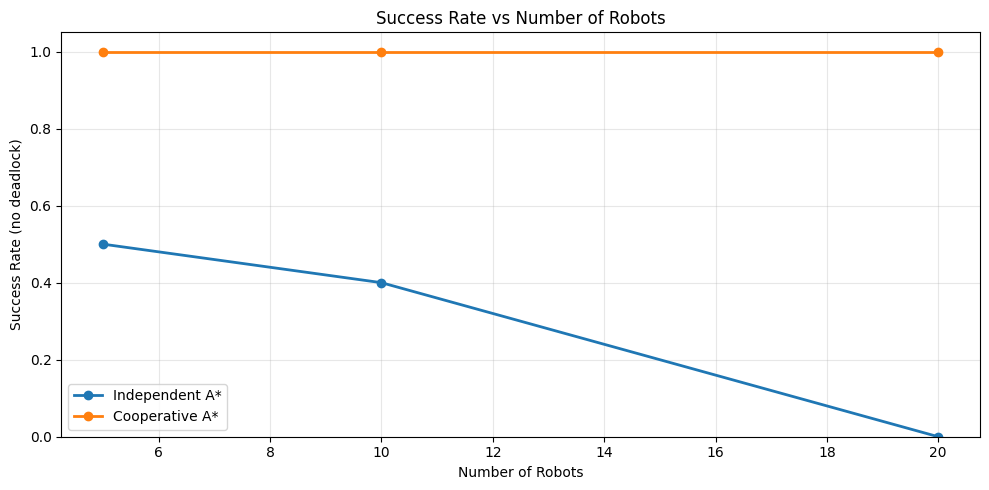

In [99]:
class SuccessRateComparison:
    """
    Compare success rate (deadlock frequency) of:
    - Independent A*
    - Cooperative A*

    Success = no conflicts detected in final paths.
    """

    def __init__(self, grid_file, fleet_sizes=(5, 10, 20), n_trials=10, seed_base=42):
        self.grid = GridEnvironment(grid_file)
        self.fleet_sizes = fleet_sizes
        self.n_trials = n_trials
        self.seed_base = seed_base
        self.results = {}

    def run(self):
        detector = ConflictDetector()

        for n in self.fleet_sizes:
            print(f"Running success-rate test for {n} robots...")

            metrics = []

            for trial in range(self.n_trials):
                seed = self.seed_base + trial * 100
                random.seed(seed)

                # HC-style robot generation
                robots = generate_random_robots(
                    self.grid,
                    n_robots=n,
                    seed=seed
                )

                initial_state = {
                    "grid": self.grid,
                    "robots": robots,
                    "positions": {r["id"]: r["start_position"] for r in robots},
                }

                # =========================
                # Independent A*
                # =========================
                ind_problem = AutomatedWarehouseRobotControllerProblem(initial_state)
                ind_solver = IndependentAStar(ind_problem)
                ind_paths = ind_solver.solve()["paths"]

                ind_conflicts = detector.detect_conflicts(ind_paths)
                ind_success = 1 if len(ind_conflicts) == 0 else 0

                # =========================
                # Cooperative A*
                # =========================
                coop_problem = AutomatedWarehouseRobotControllerProblem(initial_state)
                coop_solver = CooperativeAStar(coop_problem)
                coop_paths = coop_solver.solve()["paths"]

                coop_conflicts = detector.detect_conflicts(coop_paths)
                coop_success = 1 if len(coop_conflicts) == 0 else 0

                # store per-run results
                metrics.append({
                    "ind_success": ind_success,
                    "coop_success": coop_success,
                })

            self.results[n] = metrics

    def plot(self):
        robot_counts = sorted(self.results.keys())

        ind_success = [
            sum(m["ind_success"] for m in self.results[n]) / len(self.results[n])
            for n in robot_counts
        ]

        coop_success = [
            sum(m["coop_success"] for m in self.results[n]) / len(self.results[n])
            for n in robot_counts
        ]

        plt.figure(figsize=(10, 5))

        plt.plot(robot_counts, ind_success, marker='o', linewidth=2, label="Independent A*")
        plt.plot(robot_counts, coop_success, marker='o', linewidth=2, label="Cooperative A*")

        plt.title("Success Rate vs Number of Robots")
        plt.xlabel("Number of Robots")
        plt.ylabel("Success Rate (no deadlock)")
        plt.ylim(0, 1.05)

        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

success_rate_test = SuccessRateComparison(
    grid_file="grid.txt",
    fleet_sizes=[5, 10, 20],
    n_trials=10,
    seed_base=42
)
success_rate_test.run()
success_rate_test.plot()

### 5.1.2. Total Number Of Steps Measurement

Running for 5 robots...
Running for 20 robots...


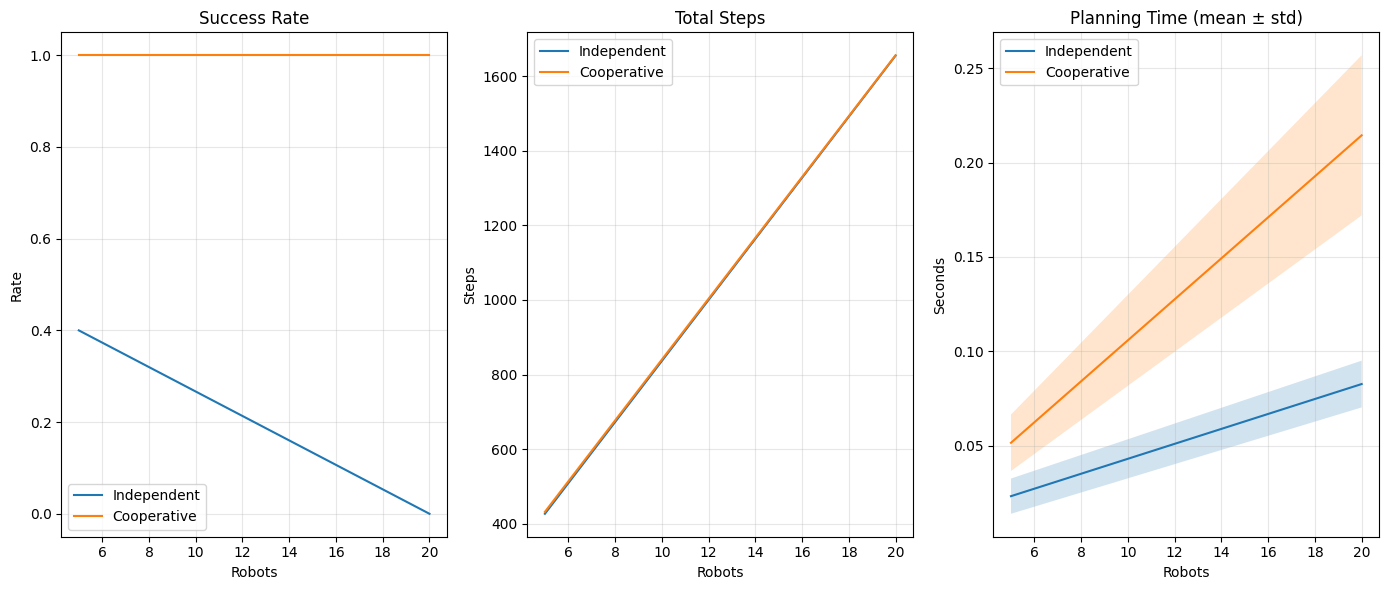


COMPARATIVE EVALUATION (Independent A* vs Cooperative A*)


,robots,ind_success_mean,coop_success_mean,ind_steps_mean,coop_steps_mean,ind_time_mean,coop_time_mean,ind_time_std,coop_time_std
0,5,0.4,1.0,427.0,432.2,0.023,0.052,0.009,0.015
1,20,0.0,1.0,1654.6,1655.6,0.083,0.214,0.012,0.042


In [100]:
class ComparativeEvaluation:
    """
    Run comparative evaluation of Independent A* vs Cooperative A*.

    For each fleet size, run multiple trials with different seeds.
    Record success rate, steps, and runtime.
    """

    def __init__(self, grid_file, fleet_sizes=(5, 10, 20), n_trials=5, seed_base=42):
        self.grid = GridEnvironment(grid_file)
        self.fleet_sizes = fleet_sizes
        self.n_trials = n_trials
        self.seed_base = seed_base
        self.results = {}

    def run(self):
        detector = ConflictDetector()

        for n in self.fleet_sizes:
            print(f"Running for {n} robots...")

            metrics = []

            for trial in range(self.n_trials):
                seed = self.seed_base + trial * 100
                random.seed(seed)

                robots = generate_random_robots(
                    self.grid,
                    n_robots=n,
                    seed=seed
                )

                initial_state = {
                    "grid": self.grid,
                    "robots": robots,
                    "positions": {r["id"]: r["start_position"] for r in robots},
                }

                # =========================
                # Independent A*
                # =========================
                t0 = time.perf_counter()

                ind_problem = AutomatedWarehouseRobotControllerProblem(initial_state)
                ind_solver = IndependentAStar(ind_problem)
                ind_paths = ind_solver.solve()["paths"]

                ind_time = time.perf_counter() - t0

                ind_conflicts = detector.detect_conflicts(ind_paths)
                ind_success = 1 if len(ind_conflicts) == 0 else 0
                ind_steps = sum(len(p) for p in ind_paths.values())

                # =========================
                # Cooperative A*
                # =========================
                t0 = time.perf_counter()

                coop_problem = AutomatedWarehouseRobotControllerProblem(initial_state)
                coop_solver = CooperativeAStar(coop_problem)
                coop_paths = coop_solver.solve()["paths"]

                coop_time = time.perf_counter() - t0

                coop_conflicts = detector.detect_conflicts(coop_paths)
                coop_success = 1 if len(coop_conflicts) == 0 else 0
                coop_steps = sum(len(p) for p in coop_paths.values())

                metrics.append({
                    "ind_success": ind_success,
                    "coop_success": coop_success,
                    "ind_steps": ind_steps,
                    "coop_steps": coop_steps,
                    "ind_time": ind_time,
                    "coop_time": coop_time,
                })

            self.results[n] = metrics

    # =========================================================
    # TABLE OUTPUT 
    # =========================================================
    def print_table(self):
        import pandas as pd
        import numpy as np

        rows = []

        for n in self.fleet_sizes:
            m = self.results[n]

            rows.append({
                "robots": n,

                "ind_success_mean": np.mean([x["ind_success"] for x in m]),
                "coop_success_mean": np.mean([x["coop_success"] for x in m]),

                "ind_steps_mean": np.mean([x["ind_steps"] for x in m]),
                "coop_steps_mean": np.mean([x["coop_steps"] for x in m]),

                "ind_time_mean": np.mean([x["ind_time"] for x in m]),
                "coop_time_mean": np.mean([x["coop_time"] for x in m]),

                # extra useful stats
                "ind_time_std": np.std([x["ind_time"] for x in m]),
                "coop_time_std": np.std([x["coop_time"] for x in m]),
            })

        df = pd.DataFrame(rows)
        df = df.round(3)

        print("\n" + "=" * 70)
        print("COMPARATIVE EVALUATION (Independent A* vs Cooperative A*)")
        print("=" * 70)

        try:
            from IPython.display import display
            display(df)
        except:
            print(df.to_string(index=False))

    # =========================================================
    # PLOTS
    # =========================================================
    def plot(self):
        import numpy as np
        import matplotlib.pyplot as plt

        robot_counts = sorted(self.results.keys())

        def mean(key):
            return [np.mean([m[key] for m in self.results[n]]) for n in robot_counts]

        def std(key):
            return [np.std([m[key] for m in self.results[n]]) for n in robot_counts]

        ind_success = mean("ind_success")
        coop_success = mean("coop_success")

        ind_steps = mean("ind_steps")
        coop_steps = mean("coop_steps")

        ind_time = mean("ind_time")
        coop_time = mean("coop_time")

        ind_time_std = std("ind_time")
        coop_time_std = std("coop_time")

        plt.figure(figsize=(14, 6))

        # =========================
        # Success Rate
        # =========================
        plt.subplot(1, 3, 1)
        plt.plot(robot_counts, ind_success, label="Independent")
        plt.plot(robot_counts, coop_success, label="Cooperative")
        plt.title("Success Rate")
        plt.xlabel("Robots")
        plt.ylabel("Rate")
        plt.legend()
        plt.grid(alpha=0.3)

        # =========================
        # Steps
        # =========================
        plt.subplot(1, 3, 2)
        plt.plot(robot_counts, ind_steps, label="Independent")
        plt.plot(robot_counts, coop_steps, label="Cooperative")
        plt.title("Total Steps")
        plt.xlabel("Robots")
        plt.ylabel("Steps")
        plt.legend()
        plt.grid(alpha=0.3)

        # =========================
        # Time 
        # =========================
        plt.subplot(1, 3, 3)
        plt.plot(robot_counts, ind_time, label="Independent")
        plt.plot(robot_counts, coop_time, label="Cooperative")

        plt.fill_between(robot_counts,
                         np.array(ind_time) - np.array(ind_time_std),
                         np.array(ind_time) + np.array(ind_time_std),
                         alpha=0.2)

        plt.fill_between(robot_counts,
                         np.array(coop_time) - np.array(coop_time_std),
                         np.array(coop_time) + np.array(coop_time_std),
                         alpha=0.2)

        plt.title("Planning Time (mean ± std)")
        plt.xlabel("Robots")
        plt.ylabel("Seconds")
        plt.legend()
        plt.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

comparative_eval = ComparativeEvaluation(grid_file="grid.txt", fleet_sizes=(5, 20), n_trials=5, seed_base=42)
comparative_eval.run()
comparative_eval.plot()
comparative_eval.print_table()

### 5.1.3. Hill Climbing Experimental Results

This module evaluates the performance of a Hill Climbing optimizer on MAPF solutions generated by A*. It introduces controlled inefficiencies into optimal paths and measures how much the optimizer can improve them across different robot densities.

It runs multiple experiments, compares metrics before and after optimization, and visualizes improvements in:

- conflicts
- makespan
- flowtime

In [101]:
import concurrent.futures

class HillClimbingBenchmarkRunner:
    def __init__(self, grid_file, robot_counts, runs_per_setting=10, seed=100, max_workers=10):
        self.grid_file = grid_file
        self.grid = GridEnvironment(grid_file)
        self.robot_counts = robot_counts
        self.runs_per_setting = runs_per_setting
        self.seed = seed
        self.max_workers = max_workers
        self.results = {}

    def _evaluate(self, optimizer, paths):
        conflicts = optimizer.conflict_detector.detect_conflicts(paths)
        makespan = max(len(p) for p in paths.values()) - 1
        flowtime = sum(len(p) - 1 for p in paths.values())
        return len(conflicts), makespan, flowtime

    def _corrupt_paths(self, paths):
        new_paths = copy.deepcopy(paths)

        for rid, path in new_paths.items():
            if path is None or len(path) < 2:
                continue

            if len(path) > 2:
                new_paths[rid] = path[:1] + [path[1], path[0]] + path[1:]

            new_paths[rid] = [path[0]] * 3 + new_paths[rid]

        return new_paths

    def _run_single_setting(self, n, run_idx):
        try:
            # We recreate grid & problem per thread to be strictly thread-safe
            local_grid = GridEnvironment(self.grid_file)
            robots = generate_random_robots(local_grid, n_robots=n, seed=self.seed + run_idx * 100)
            
            initial_state = {
                "grid": local_grid,
                "robots": robots,
                "positions": {r["id"]: r["start_position"] for r in robots},
                "collsions": 0,
                "deadlock": False,
            }

            problem = AutomatedWarehouseRobotControllerProblem(initial_state)
            solver = CooperativeAStar(problem)
            initial_paths = solver.solve()["paths"]

            corrupted = self._corrupt_paths(initial_paths)

            optimizer = HillClimbingOptimizer(ConflictDetector())
            optimized = optimizer.optimize(corrupted, local_grid)

            init = self._evaluate(optimizer, corrupted)
            opt = self._evaluate(optimizer, optimized)

            return {
                "initial": init,
                "optimized": opt,
                "iterations": optimizer.iteration_count
            }
        except Exception as e:
            print(f"Failed run: {e}")
            return None

    def run(self):
        # We use a ThreadPoolExecutor since Notebooks usually handle it better than processes, 
        # and limit to the 10 CPU cores requested.
        for n in self.robot_counts:
            print(f"Running for {n} robots on {self.max_workers} CPU cores...")
            
            metrics = []
            
            with concurrent.futures.ThreadPoolExecutor(max_workers=self.max_workers) as executor:
                futures = [executor.submit(self._run_single_setting, n, i) for i in range(self.runs_per_setting)]
                
                for future in concurrent.futures.as_completed(futures):
                    res = future.result()
                    if res:
                        metrics.append(res)

            self.results[n] = metrics

    def plot(self):
        robot_counts = sorted(self.results.keys())

        avg_init_conf = [sum(m["initial"][0] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]
        avg_opt_conf  = [sum(m["optimized"][0] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]

        avg_init_mkp  = [sum(m["initial"][1] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]
        avg_opt_mkp   = [sum(m["optimized"][1] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]

        avg_init_flow = [sum(m["initial"][2] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]
        avg_opt_flow  = [sum(m["optimized"][2] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]

        plt.figure(figsize=(14, 6))

        plt.subplot(1, 3, 1)
        plt.plot(robot_counts, avg_init_conf, label="Initial")
        plt.plot(robot_counts, avg_opt_conf, label="Optimized")
        plt.title("Conflicts")
        plt.xlabel('Number of Robots')
        plt.ylabel('Average Conflicts')
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(robot_counts, avg_init_mkp, label="Initial")
        plt.plot(robot_counts, avg_opt_mkp, label="Optimized")
        plt.title("Makespan")
        plt.xlabel('Number of Robots')
        plt.ylabel('Average Makespan')
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(robot_counts, avg_init_flow, label="Initial")
        plt.plot(robot_counts, avg_opt_flow, label="Optimized")
        plt.title("Flowtime")
        plt.xlabel('Number of Robots')
        plt.ylabel('Average Flowtime')
        plt.legend()

        plt.tight_layout()
        plt.show()

### Vectorized Neighborhood Evaluation (CUDA Consideration)

While Python-level loop searches control the paths sequentially, large-scale Multi-Agent Pathfinding scenarios can offload **neighborhood conflict checking** directly to the GPU using PyTorch or CuPy. By padding all proposed path modifications (the "detours") into multi-dimensional tensors (e.g., shape `[batch_size, num_agents, max_time, 2]`), a GPU can simultaneously verify thousands of potential Hill Climbing variations mathematically across millions of cells instantly using vector broadcasting instead of iterative hash-set lookups, leaving the CPU completely unbound to manage purely the search nodes.

#### The experiment is executed for multiple robot densities to measure scalability and performance trends.

Running for 10 robots on 10 CPU cores...
Running for 20 robots on 10 CPU cores...
Running for 25 robots on 10 CPU cores...


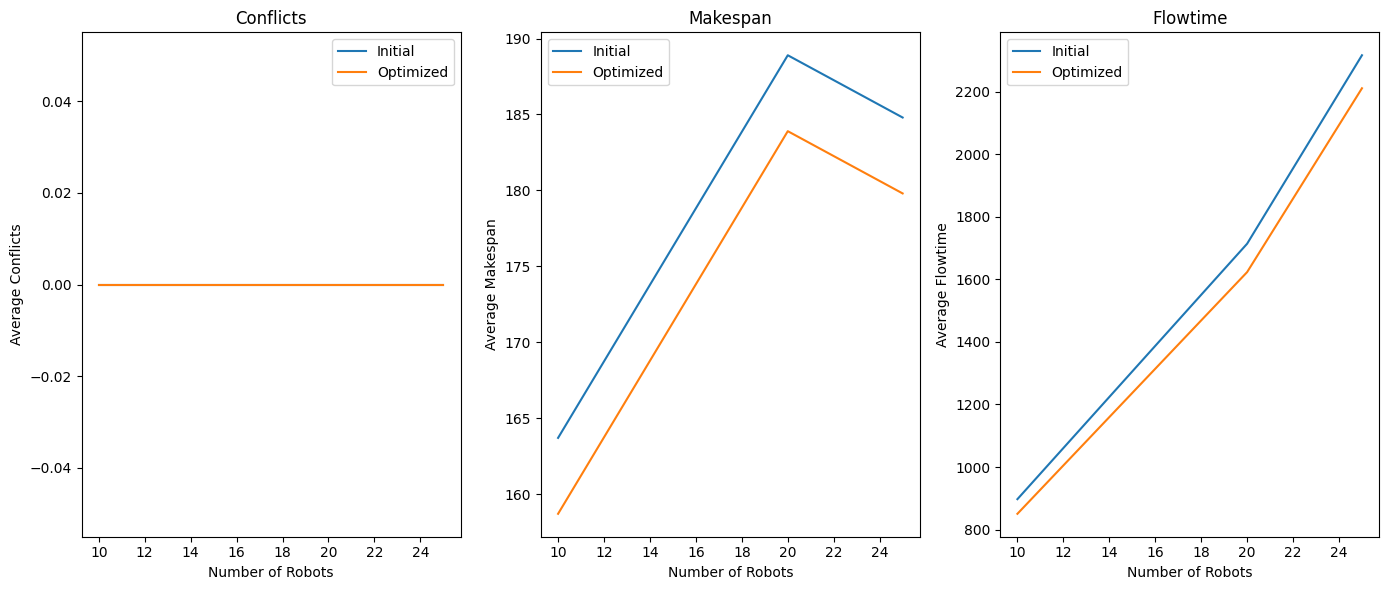

In [102]:
runner = HillClimbingBenchmarkRunner(
    grid_file="grid.txt",
    robot_counts=[10, 20, 25],
    runs_per_setting=10
)

runner.run()
runner.plot()

### 5.1.4. Performance Statistics of Multiple CBS Runs

This class runs multiple CBS (Conflict-Based Search) experiments across different robot counts to evaluate performance under varying problem sizes.

It:

- Generates random MAPF instances
- Runs CBS multiple times per scenario
- Collects metrics such as success rate, makespan, flowtime, and search effort
- Aggregates results over repeated trials
- Produces comparative plots across robot scales

It provides a clean way to benchmark CBS scalability and efficiency in multi-agent pathfinding environments.

In [103]:
class CBSBenchmarkRunner:
    def __init__(
        self,
        grid_file: str,
        robot_counts,
        runs_per_setting: int = 10,
        time_limit: int = 20
    ):
        self.grid = GridEnvironment(grid_file)
        self.robot_counts = robot_counts
        self.runs_per_setting = runs_per_setting
        self.time_limit = time_limit
        self.results = {}

    def _create_problem(self, robots):
        initial_state = {
            "grid": self.grid,
            "robots": robots,
            "positions": {r["id"]: r["start_position"] for r in robots},
            "collsions": 0,
            "deadlock": False,
        }
        return AutomatedWarehouseRobotControllerProblem(initial_state)

    def run(self):
        for n in self.robot_counts:
            print(f"Running CBS for {n} robots...")

            robots = generate_random_robots(self.grid, n_robots=n)
            metrics = []

            for _ in range(self.runs_per_setting):

                problem = self._create_problem(robots)

                cbs = ConflictBasedSearch(
                    problem,
                    CooperativeAStar,
                    conflict_detector=ConflictDetector(),
                    objective="flowtime"
                )

                result = cbs.solve(time_limit=self.time_limit)

                metrics.append(result)

            self.results[n] = metrics

        return self.results

    def plot(self):
        import matplotlib.pyplot as plt

        robot_counts = sorted(self.results.keys())

        success = [sum(m["success"] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]
        makespan = [sum(m["makespan"] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]
        flowtime = [sum(m["flowtime"] for m in self.results[n]) / len(self.results[n]) for n in robot_counts]

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 3, 1)
        plt.plot(robot_counts, success, marker="o")
        plt.title("Success Rate")
        plt.xlabel('Number of Robots')
        plt.ylabel('Average Success Rate')

        plt.subplot(1, 3, 2)
        plt.plot(robot_counts, makespan, marker="o")
        plt.title("Makespan")
        plt.xlabel('Number of Robots')
        plt.ylabel('Average Makespan')

        plt.subplot(1, 3, 3)
        plt.plot(robot_counts, flowtime, marker="o")
        plt.title("Flowtime")
        plt.xlabel('Number of Robots')
        plt.ylabel('Average Flowtime')

        plt.tight_layout()
        plt.show()

#### The experiment is executed for multiple robot densities to measure scalability and performance trends.

Running CBS for 10 robots...
Running CBS for 20 robots...
Running CBS for 25 robots...


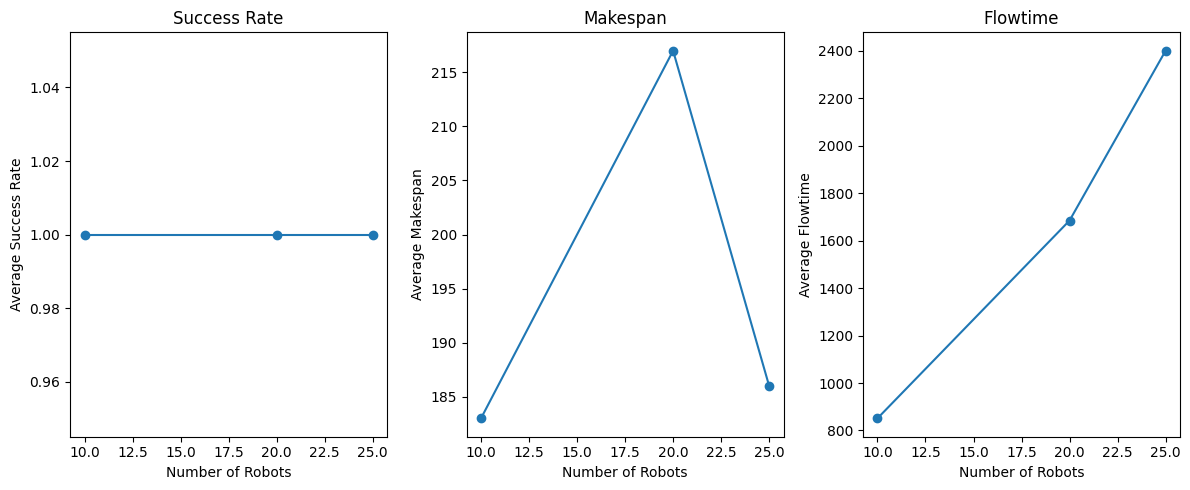

In [104]:
runner = CBSBenchmarkRunner(
    grid_file="grid.txt",
    robot_counts=[10, 20, 25],
    runs_per_setting=10,
    time_limit=20
)

runner.run()
runner.plot()

## 5.2. Success Criteria

### 5.2.1. Visual demonstration

### WarehouseSimulationGUI Class:

A modular animation system for MAPF warehouse simulations that visualizes robot movement on a grid.


In [105]:
class WarehouseSimulationGUI:
    """
    GUI animation system for MAPF robot simulations.

    Features:
    - Animated robot movement
    - Unique robot colors
    - Start/goal markers
    - Motion trails
    - Optional GIF export
    """

    def __init__(
        self,
        grid: GridEnvironment = None,
        n_robots: int = 10,
        seed: int = 2024,
        figsize=(10, 8),
        interval=250, 
        robots=None
    ):
        self.grid = grid
        self.n_robots = n_robots
        self.seed = seed
        self.figsize = figsize
        self.interval = interval
        self.robots = robots

        self.problem = None
        self.paths = None
        self.padded_paths = None
        self.anim = None

    def build(self):

        if self.robots is None:
            self.robots = generate_random_robots(self.grid, n_robots=self.n_robots, seed=self.seed)   

        initial_state = {
            "grid": self.grid,
            "robots": self.robots,
            "positions": {
                r["id"]: r["start_position"]
                for r in self.robots
            },
            "collsions": 0,
            "deadlock": False,
        }

        self.problem = AutomatedWarehouseRobotControllerProblem(initial_state)

        return self


    def solve(self, solver_class=CooperativeAStar):
        solver = solver_class(self.problem)

        result = solver.solve()
        self.paths = result["paths"]
        self.padded_paths = self.pad_paths(self.paths)

        return result
    
    @staticmethod
    def pad_paths(paths):
        """
        Extend shorter paths by repeating the last position.
        """
        if not paths:
            return {}

        max_len = max(len(p) for p in paths.values())

        return {rid: p + [p[-1]] * (max_len - len(p)) for rid, p in paths.items()}

    def animate(self, save_gif: bool = False, gif_name="simulation.gif"):
        from IPython.display import HTML, display as ipy_display

        padded = self.padded_paths
        rids = list(padded.keys())
        max_t = max(len(p) for p in padded.values())

        colors = plt.cm.rainbow(
            np.linspace(0, 1, len(rids))
        )

        fig, ax = plt.subplots(figsize=self.figsize)

        # White = walkable, black = obstacle
        ax.imshow(
            np.array(self.grid.grid),
            cmap="gray",
            origin="upper",
            alpha=0.5
        )

        # Robot lookup by ID
        robot_map = {
            r["id"]: r
            for r in self.robots
        }

        # Draw start/goal markers
        for i, rid in enumerate(rids):
            robot = robot_map[rid]

            sx, sy = robot["start_position"]
            gx, gy = robot["goal_position"]

            ax.plot(
                sx, sy,
                "o",
                color=colors[i],
                markersize=8,
                zorder=4
            )

            ax.plot(
                gx, gy,
                "*",
                color=colors[i],
                markersize=10,
                zorder=4
            )

        # Moving robots
        scat = ax.scatter([], [], s=120, zorder=6)

        # Trails
        trail_lines = [
            ax.plot(
                [],
                [],
                "-",
                color=colors[i],
                alpha=0.4,
                lw=1.5
            )[0]
            for i in range(len(rids))
        ]

        title_txt = ax.set_title("")

        def _init():
            scat.set_offsets(np.empty((0, 2)))

            for ln in trail_lines:
                ln.set_data([], [])

            return [scat] + trail_lines


        def _update(frame):

            # Current robot positions
            pts = np.array([
                padded[rid][frame]
                for rid in rids
            ])

            scat.set_offsets(pts)
            scat.set_color(colors[:len(rids)])

            # Trails
            for i, rid in enumerate(rids):

                traj = padded[rid][
                    max(0, frame - 15): frame + 1
                ]

                xs, ys = zip(*traj)

                trail_lines[i].set_data(xs, ys)

            title_txt.set_text(
                f"Step {frame + 1}/{max_t}  |  Robots: {len(rids)}"
            )

            return [scat] + trail_lines + [title_txt]
        
        self.anim = animation.FuncAnimation(
            fig,
            _update,
            frames=max_t,
            init_func=_init,
            blit=False,
            interval=self.interval
        )

        plt.tight_layout()
        plt.close(fig)

        if save_gif:
            self.anim.save(
                gif_name,
                writer="pillow",
                fps=4
            )

            print(f"✔ Simulation saved → {gif_name}")

        ipy_display(
            HTML(self.anim.to_jshtml())
        )


### Simulation Test:

Successful simultaneous navigation of 10 robots within the environment without collisions or deadlocks.

In [106]:
sim = WarehouseSimulationGUI(
    grid=GridEnvironment(filename="grid.txt"),
    n_robots=10,
    seed=2024
)

sim.build()

sim.solve(CooperativeAStar)

sim.animate(save_gif=False)

### 5.2.2. Head On Collision Scenario

In [107]:
# Head on Head collision scenario
grid = GridEnvironment(filename="grid.txt", size=(7, 2))
robots = [
    {
        'id': 0,
        'start_position': (0, 0),
        'goal_position': (6, 0),
        'at_goal': False,
    },
    {
        'id': 1,
        'start_position': (6, 0),
        'goal_position': (0, 0),
        'at_goal': False,
    }
]

head_collsion_sim = WarehouseSimulationGUI(
    grid=grid,
    n_robots=2,
    seed=2024,
    robots=robots
)

head_collsion_sim.build()

head_collsion_sim.solve(CooperativeAStar)

head_collsion_sim.animate(save_gif=False)


# 6. Deliverables

## 6.1. Working Prototype

In Section 5.1, we introduced the `WarehouseSimulationGUI` class for visualizing multi-robot movement on grid environments. This module enables easy testing across different maps and robot densities, with real-time animation of paths, start/goal positions, and motion trails.

To improve usability, a web-based application is also provided (https://mapf-ai.vercel.app/), allowing users to interactively configure grid environments and highlight corridor cells through a simple interface.

## 6.2. Visualizations

### MAPFConflictHeatmapAnalyzer Class:

This class provides a visualization and analysis framework for studying congestion and collision patterns in Multi-Agent Path Finding (MAPF) environments.

It repeatedly generates random robot scenarios, executes a selected MAPF solver, detects conflicts between agents, and aggregates the results into a conflict density heatmap.

In [108]:
class MAPFConflictHeatmapAnalyzer:

    """
    Conflict density analyzer for MAPF algorithms.

    Features:
    - Independent A* or Cooperative A*
    - Parallel execution
    - Raw or smoothed heatmaps
    - Automatic conflict aggregation
    - PNG export
    - Corridor and hotspot identification
    """

    def __init__(
        self,
        grid_file: str,
        solver_type: str = "independent",   # "independent" or "cooperative"
        n_robots: int = 100,
        n_tests: int = 30,
        max_workers: int = 10,
        save_plots: bool = False
    ):
        self.grid_file = grid_file
        self.solver_type = solver_type.lower()
        self.n_robots = n_robots
        self.n_tests = n_tests
        self.max_workers = max_workers
        self.save_plots = save_plots
        self.grid = GridEnvironment(filename=grid_file)

        self.total_conflict_density = defaultdict(int)
        self.heatmap = None
        self.analysis_completed = False

    # ============================================================
    # SOLVER FACTORY
    # ============================================================

    def _create_solver(self, problem):

        if self.solver_type == "cooperative":
            return CooperativeAStar(problem)

        return IndependentAStar(problem)

    # ============================================================
    # SINGLE TEST
    # ============================================================

    def _run_single_test(self, seed_val):

        print(f"Starting test run {seed_val + 1}...")

        robots = generate_random_robots(
            self.grid,
            n_robots=self.n_robots,
            seed=seed_val
        )

        initial_state = {
            "robots": robots,
            "positions": {
                r["id"]: r["start_position"]
                for r in robots
            },
            "grid": self.grid,
            "collisions": 0,
            "deadlock": False
        }

        problem = AutomatedWarehouseRobotControllerProblem(
            initial_state
        )

        solver = self._create_solver(problem)

        result = solver.solve()

        conflict_report = ConflictDetector().get_report(
            result["paths"]
        )

        density = defaultdict(int)

        for conflict in conflict_report:

            if conflict["type"] == "vertex":
                pos = conflict["pos"]
                density[pos] += 1

        return density

    # ============================================================
    # RUN ANALYSIS
    # ============================================================

    def run(self):

        self.total_conflict_density = defaultdict(int)

        # Jupyter on Windows can spawn child processes that cannot reliably
        # import notebook-defined classes, so fall back to threads there.
        try:
            in_notebook = get_ipython() is not None
        except NameError:
            in_notebook = False

        executor_cls = (
            concurrent.futures.ThreadPoolExecutor
            if in_notebook
            else concurrent.futures.ProcessPoolExecutor
        )

        with executor_cls(
            max_workers=self.max_workers
        ) as executor:

            results = executor.map(
                self._run_single_test,
                range(self.n_tests)
            )

            for density_slice in results:

                for pos, count in density_slice.items():

                    self.total_conflict_density[pos] += count

        self._build_heatmap()

        self.analysis_completed = True

        return self.heatmap

    # ============================================================
    # BUILD HEATMAP
    # ============================================================

    def _build_heatmap(self):

        self.heatmap = np.zeros(
            (self.grid.height, self.grid.width)
        )

        for (x, y), count in self.total_conflict_density.items():

            self.heatmap[y][x] = count

    # ============================================================
    # GRID MASK
    # ============================================================

    def _build_grid_mask(self):

        grid_mask = np.zeros(
            (self.grid.height, self.grid.width)
        )

        for y in range(self.grid.height):

            for x in range(self.grid.width):

                if not self.grid.is_walkable(x, y):

                    grid_mask[y][x] = 1

        return grid_mask

    # ============================================================
    # PLOT
    # ============================================================

    def plot(
        self,
        smooth: bool = False,
        sigma: float = 1.5,
        figsize=(18, 8),
        save=True
    ):

        if self.heatmap is None:
            raise ValueError("Run analysis first using .run()")

        data = self.heatmap.copy()

        title = "Conflict Density Heatmap"
        filename = f"{self.solver_type}_heatmap.png"

        # --------------------------------------------------------
        # SMOOTHING
        # --------------------------------------------------------

        if smooth:

            from scipy.ndimage import gaussian_filter

            data = gaussian_filter(
                data.astype(float),
                sigma=sigma
            )

            masked = np.ma.masked_where(
                data < 0.05,
                data
            )

            title = "Smoothed Conflict Density Heatmap"
            filename = f"{self.solver_type}_smoothed_heatmap.png"

            interpolation = "bilinear"

        else:

            masked = np.ma.masked_where(
                data == 0,
                data
            )

            interpolation = "nearest"

        # --------------------------------------------------------
        # DRAW
        # --------------------------------------------------------

        grid_mask = self._build_grid_mask()

        plt.figure(figsize=figsize)

        # Background grid
        plt.imshow(
            grid_mask,
            cmap="gray_r",
            origin="upper",
            alpha=0.3
        )

        # Heatmap
        im = plt.imshow(
            masked,
            cmap="hot_r",
            origin="upper",
            alpha=0.9,
            interpolation=interpolation
        )

        plt.colorbar(im, label="Conflict Count")

        plt.title(title)
        plt.xlabel("X")
        plt.ylabel("Y")

        # --------------------------------------------------------
        # SAVE
        # --------------------------------------------------------

        if self.save_plots:

            plt.savefig(
                filename,
                dpi=300,
                bbox_inches="tight"
            )

            print(f"Saved plot → {filename}")

        plt.show()

    # ============================================================
    # Stats
    # ============================================================

    def show_top_conflict_corridors(
        self,
        top_k: int = 10,
        min_conflicts: int = 1
    ):
        """
        Display the cells/corridors with the highest conflict density.
        """

        if not self.analysis_completed:
            raise ValueError("Run analysis first using .run()")
        
        if len(self.total_conflict_density) == 0:
            print("\nNo conflicts detected in any simulation.")
            return

        # Sort descending by conflict count
        ranked = sorted(
            self.total_conflict_density.items(),
            key=lambda x: x[1],
            reverse=True
        )

        # Filter minimum threshold
        ranked = [
            (pos, count)
            for pos, count in ranked
            if count >= min_conflicts
        ]

        print("\n" + "=" * 50)
        print("TOP CONFLICT CORRIDORS")
        print("=" * 50)

        for i, ((x, y), count) in enumerate(ranked[:top_k], start=1):

            print(
                f"{i:02d}. Cell ({x}, {y}) "
                f"→ {count} conflicts"
            )

### Independent A* Heatmap Analysis

This experiment evaluates the behavior of the Independent A* strategy using 100 robots across 30 randomized simulations.

Starting test run 1...
Starting test run 2...
Starting test run 3...
Starting test run 4...
Starting test run 5...
Starting test run 6...
Starting test run 7...
Starting test run 8...
Starting test run 9...
Starting test run 10...
Total conflicts detected: 120
  1. swap at t=6 involving robots [13, 77]
  2. vertex at t=8 involving robots [48, 79]
  3. vertex at t=9 involving robots [20, 76]
  4. vertex at t=9 involving robots [30, 43]
  5. swap at t=9 involving robots [30, 75]
  6. swap at t=9 involving robots [34, 67]
  7. vertex at t=10 involving robots [13, 29]
  8. vertex at t=11 involving robots [49, 60]
  9. swap at t=11 involving robots [13, 19]
  10. swap at t=13 involving robots [59, 97]
  ... and 110 more.
Starting test run 11...
Total conflicts detected: 146
  1. swap at t=1 involving robots [8, 52]
  2. vertex at t=2 involving robots [47, 95]
  3. vertex at t=2 involving robots [58, 67]
  4. swap at t=2 involving robots [2, 3]
  5. vertex at t=3 involving robots [47, 95]
  

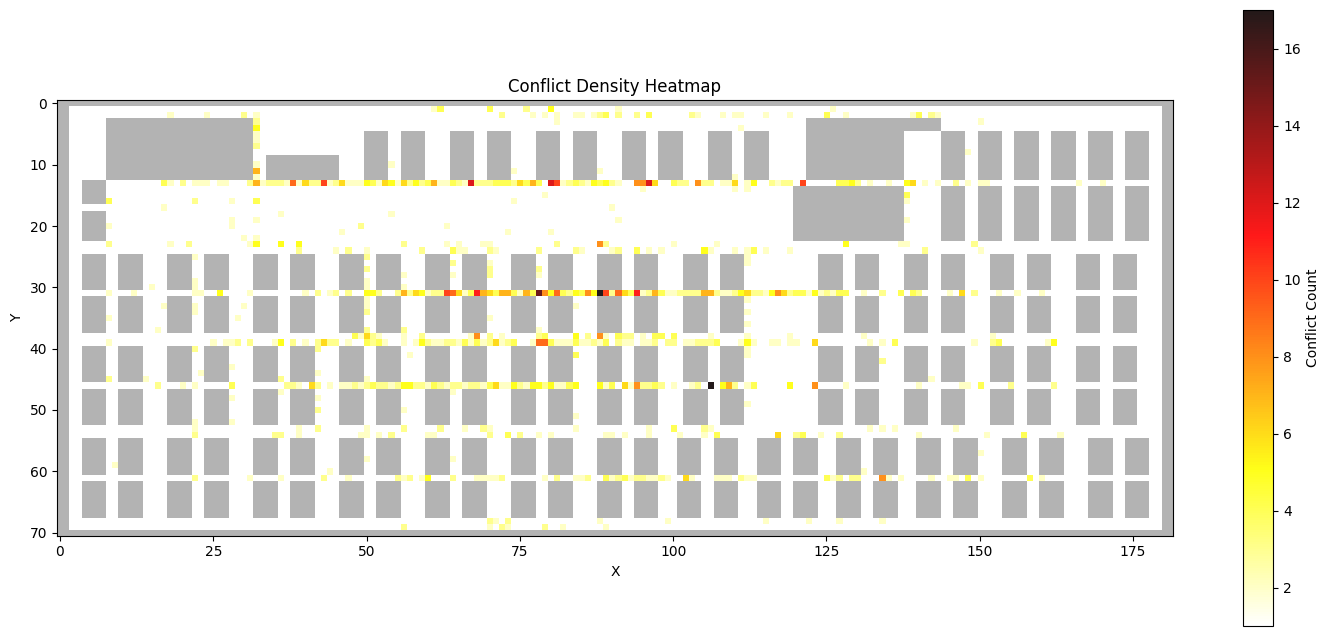

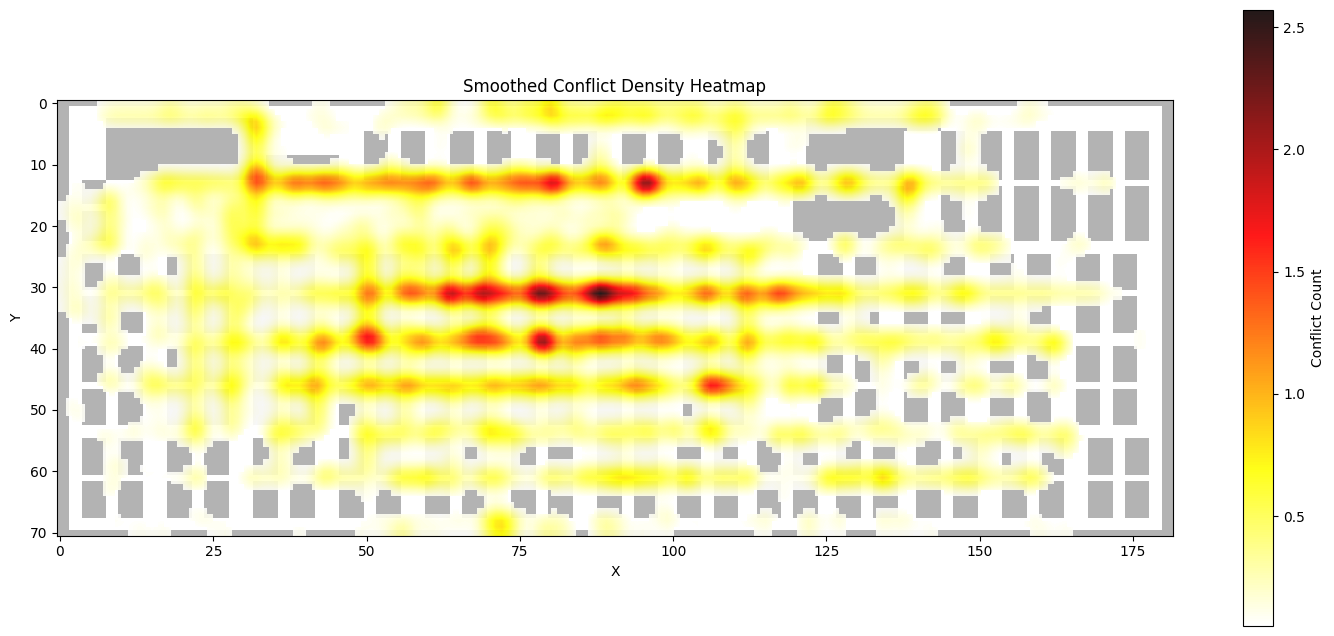


TOP CONFLICT CORRIDORS
01. Cell (88, 31) → 17 conflicts
02. Cell (106, 46) → 17 conflicts
03. Cell (78, 31) → 15 conflicts
04. Cell (80, 13) → 12 conflicts
05. Cell (67, 13) → 12 conflicts
06. Cell (96, 13) → 12 conflicts
07. Cell (68, 31) → 11 conflicts
08. Cell (94, 31) → 11 conflicts
09. Cell (81, 13) → 10 conflicts
10. Cell (121, 13) → 10 conflicts


In [109]:
independent_astar_analyzer = MAPFConflictHeatmapAnalyzer(
    grid_file="grid.txt",
    solver_type="independent",   
    n_robots=100,
    n_tests=30,
    max_workers=10
)

independent_astar_analyzer.run()

# Raw heatmap
independent_astar_analyzer.plot(smooth=False)

# Smoothed heatmap
independent_astar_analyzer.plot(smooth=True, sigma=1.5)

# Print top conflict corridors
independent_astar_analyzer.show_top_conflict_corridors(top_k=10, min_conflicts=5)

### Cooperative A* Heatmap Analysis

This experiment evaluates the behavior of the Cooperative A* strategy using 100 robots across 30 randomized simulations.

Starting test run 1...
Starting test run 2...
Starting test run 3...
Starting test run 4...
Starting test run 5...
Starting test run 6...
Starting test run 7...
Starting test run 8...
Starting test run 9...
Starting test run 10...
Total conflicts detected: 0
Starting test run 11...
Total conflicts detected: 0
Starting test run 12...
Total conflicts detected: 0
Starting test run 13...
Total conflicts detected: 0
Starting test run 14...
Total conflicts detected: 0
Starting test run 15...
Total conflicts detected: 0
Starting test run 16...
Total conflicts detected: 0
Starting test run 17...
Total conflicts detected: 0
Starting test run 18...
Total conflicts detected: 0
Starting test run 19...
Total conflicts detected: 0
Starting test run 20...
Total conflicts detected: 0Total conflicts detected: 0
Starting test run 21...

Starting test run 22...
Total conflicts detected: 0Total conflicts detected: 0
Starting test run 23...

Starting test run 24...
Total conflicts detected: 0
Starting test

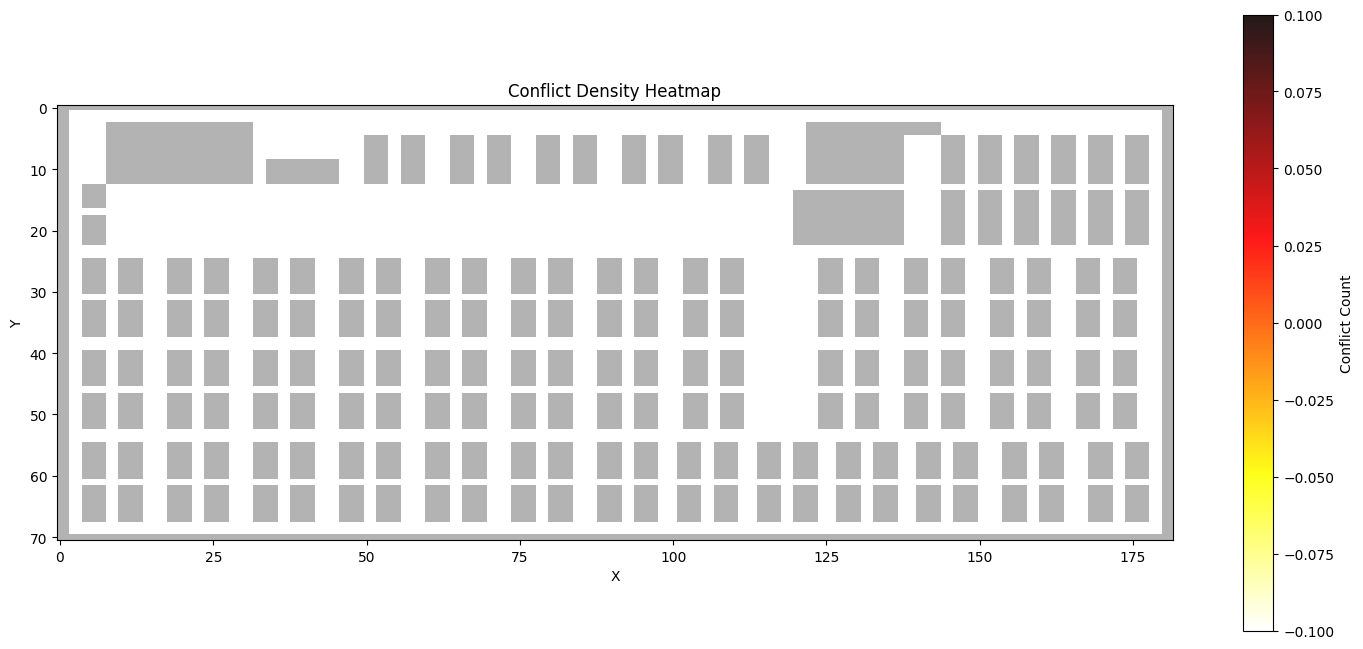

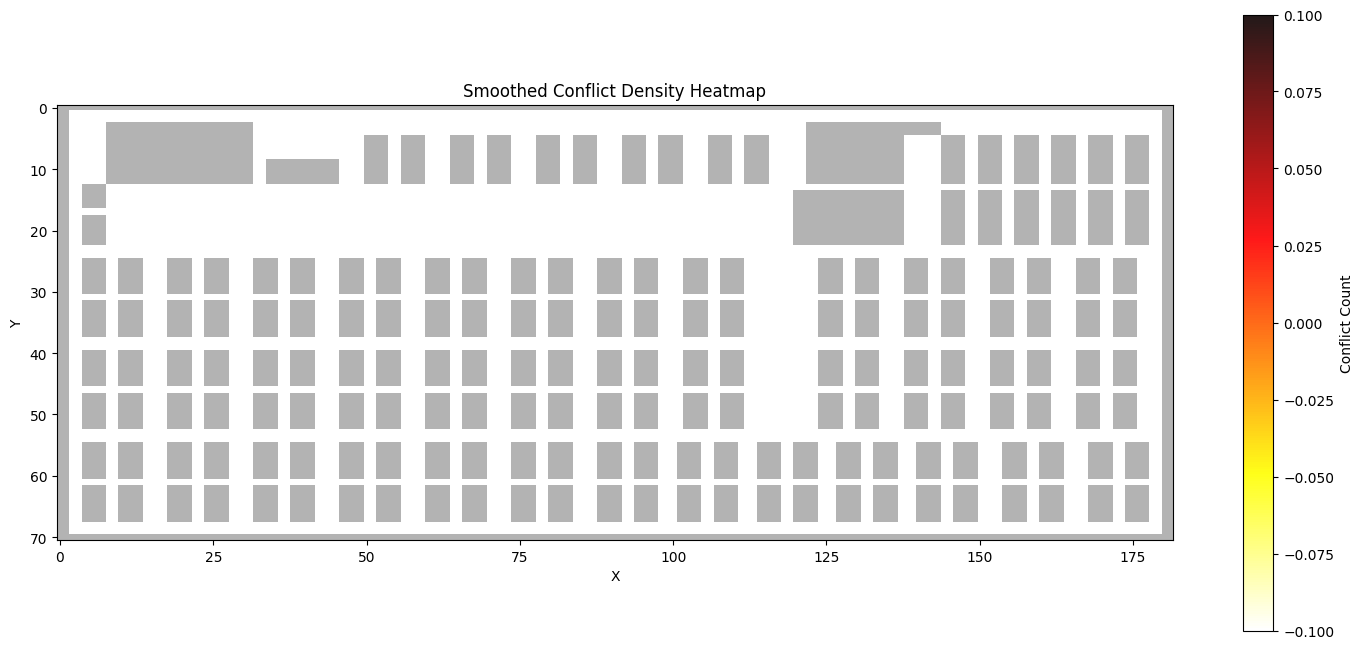


No conflicts detected in any simulation.


In [110]:
cooperative_astar_analyzer = MAPFConflictHeatmapAnalyzer(
    grid_file="grid.txt",
    solver_type="cooperative",   
    n_robots=100,
    n_tests=30,
    max_workers=10
)

cooperative_astar_analyzer.run()

# Raw heatmap
cooperative_astar_analyzer.plot(smooth=False)

# Smoothed heatmap
cooperative_astar_analyzer.plot(smooth=True, sigma=1.5)

# Print top conflict corridors
cooperative_astar_analyzer.show_top_conflict_corridors(top_k=10, min_conflicts=5)

## 6.3. Documentation

### Collision-Checking Logic in the Time Dimension

#### Overview

The system performs collision checking in a **time-expanded space**, where each robot path is represented as a sequence of `(x, y)` positions indexed by discrete time steps `t`. A collision is both spatial and **temporal**—two robots cannot occupy the same cell or traverse conflicting edges simultaneously.

---

#### 1. Time Alignment: Path Padding

##### Function: `pad_paths(paths)`

All robot paths must have equal temporal length before collision detection:

- Each robot stays at its **goal position indefinitely**
- All paths padded to: `max_time = max(len(path))`

**Effect:** `..., goal, goal, goal, ...`

This ensures collision detection works on a shared time horizon.

---

#### 2. Vertex Conflicts (Same Cell, Same Time)

**Definition:** Two or more robots occupy the same position at time `t`.

**Check:**
```
(P.x, P.y, t) ∈ reservation_table
```

**Implementation:**
```python
def _check_vertex_conflict(pos, t, reservation_table):
    return (pos[0], pos[1], t) in reservation_table
```

**Formal Condition:**
```
∃ t, ∃ pos such that:
|{r | p_r(t) = pos}| > 1
```

---

#### 3. Swap Conflicts (Edge Crossing / Head-On)

**Definition:** Two robots exchange positions in one time step:
```
Robot A: U → V  (at step t-1 → t)
Robot B: V → U  (at step t-1 → t, same time)
```
They cross on the shared edge.

**Check:**
```
other_was_at_destination = (V.x, V.y, t-1) ∈ table
other_goes_to_source     = (U.x, U.y, t)   ∈ table
return both true
```

**Implementation:**
```python
def _check_edge_conflict(pos_from, pos_to, t, reservation_table):
    other_was_at_to   = (pos_to[0], pos_to[1], t-1) in reservation_table
    other_goes_to_src = (pos_from[0], pos_from[1], t) in reservation_table
    return other_was_at_to and other_goes_to_src
```

---

#### 4. A* Reservation Table (Planning Layer)

Uses 3D reservation: `(x, y, t)`

##### Vertex Constraint Check

A move is invalid if:
```
(x, y, t) ∈ reservation_table
```

**Implementation:** `_check_vertex_conflict(pos, t, reservation_table)`

##### Edge Constraint Check (Time-Aware Transition)

A move from `A → B` at time `t → t+1` is invalid if:

- Another robot was at `B` at time `t`, OR
- Another robot moves from `B → A` at the same step

**Implementation:** `_check_edge_conflict(pos_from, pos_to, t, reservation_table)`

---

#### 5. Reservation Table Construction (Time Expansion)

##### Function: `_build_reservation_table(paths)`

Each path is expanded into time-space occupancy:

```
For each robot:
  For each (x, y, t) in path:
    reservation_table.add((x, y, t))
```

**Goal Extension:** After path ends, goal cell is reserved for **500 additional time steps**:

```
goal_reserved_until = path_end + 500
Prevents later robots from 'running through' waiting robots
```

**Performance:** O(1) hash-set lookup for each cell/time check

**Effects:**
- Robots cannot pass through finished robots
- Goal occupation is permanent
- Single hash-set contains test is key performance advantage

---

#### 6. CBS-Level Temporal Constraint Conversion

In **Conflict-Based Search**, the reservation table is replaced by explicit **Constraint lists** per agent.

**Branching on Conflict:**

When a conflict is detected at `(pos, t)`:

```
Conflict Tree branches into two:
  ├─ Branch A: Add Constraint(robot_A, pos, t)  
  │            → Robot A cannot be at pos at time t
  │            → Robot A replans
  │
  └─ Branch B: Add Constraint(robot_B, pos, t)
               → Robot B replans
```

**Guarantees:**
- **Completeness:** Always finds solution if one exists
- **Optimality:** Solution optimal w.r.t. chosen objective
- **vs Cooperative A*:** CBS is complete; cooperative A* is not

**Constraint Types:**

| Conflict Type | Constraint | Effect |
|---|---|---|
| Vertex Conflict | `Constraint(agent, pos, time)` | Agent cannot be at `pos` at `time` |
| Swap Conflict | `Constraint(agent, pos1, pos2, time)` | Agent cannot move `pos1 → pos2` at `time` |
